# Exploratory Data Analysis - Google Brain Ventilator Pressure Prediction
This notebook provides a complete exploratory data analysis for the Kaggle project “Google Brain - Ventilator Pressure Prediction

## Libraries importation

In [1]:
# Standard librairies
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
files.upload()

Mounted at /content/drive


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"quangghuyyy","key":"e28122fd3e8f6742795d5d701f36705d"}'}

In [2]:
import os
import shutil

os.makedirs("/root/.config/kaggle", exist_ok=True)

shutil.move("kaggle.json", "/root/.config/kaggle/kaggle.json")

'/root/.config/kaggle/kaggle.json'

## 1.1 Data loading

In [3]:
import os
import pandas as pd
from kaggle.api.kaggle_api_extended import KaggleApi
import zipfile

class VentilatorDataLoader:
    """
    Classe pour charger les données du challenge Ventilator Pressure Prediction
    """

    def __init__(self, data_dir='data'):
        """
        Initialise le chargeur de données

        Args:
            data_dir: Répertoire où stocker/chercher les données
        """
        self.data_dir = data_dir
        os.makedirs(data_dir, exist_ok=True)

    def load_data(self):
        """
        Charge les données depuis Kaggle ou les télécharge si nécessaire

        Returns:
            tuple: (train_df, test_df, submission_df)
        """

        # Télécharger les données
        self._download_data()

        # Charger les données téléchargées
        train_df = pd.read_csv(os.path.join(self.data_dir, 'train.csv'))
        test_df = pd.read_csv(os.path.join(self.data_dir, 'test.csv'))
        submission_df = pd.read_csv(os.path.join(self.data_dir, 'sample_submission.csv'))
        print("Données téléchargées et chargées avec succès.")

        return train_df, test_df, submission_df

    def _download_data(self):
        print("Téléchargement des données avec l'API Kaggle...")
        zip_path = os.path.join(self.data_dir, 'ventilator-pressure-prediction.zip')
        train_csv_path = os.path.join(self.data_dir, 'train.csv')
        test_csv_path = os.path.join(self.data_dir, 'test.csv')

        if os.path.exists(train_csv_path) and os.path.exists(test_csv_path):
            print("Les fichiers de données existent déjà, pas de téléchargement.")
            return

        # Initier l’API
        api = KaggleApi()
        api.authenticate()

        # Télécharger le dataset dans le dossier data
        api.competition_download_files('ventilator-pressure-prediction', path=self.data_dir)

        # Décompresser le fichier
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(self.data_dir)

        print("Téléchargement et extraction terminés.")


In [4]:
# Créer une instance du chargeur de données
data_loader = VentilatorDataLoader(data_dir='./data')

# Charger les données
train_df, test_df, submission_df = data_loader.load_data()

# Afficher les informations sur les données
print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'Sample submission shape: {submission_df.shape}')

Téléchargement des données avec l'API Kaggle...
Téléchargement et extraction terminés.
Données téléchargées et chargées avec succès.
Train shape: (6036000, 8)
Test shape: (4024000, 7)
Sample submission shape: (4024000, 2)


## 1.2 Statistic analysis of features

In [5]:
import pandas as pd
import numpy as np
from tqdm import tqdm

class VentilatorDataPreprocessor:
    """
    Classe pour le prétraitement des données
    """

    def analyze_dataset(self, df, title):
        """
        Fournit une analyse statistique d'un dataframe

        Args:
            df: DataFrame à analyser
            title: Titre de l'analyse

        Returns:
            dict: Dictionnaire contenant les statistiques principales
        """
        stats = {
            'shape': df.shape,
            'head': df.head(),
            'info': df.info(),
            'describe': df.describe(),
            'null_counts': df.isnull().sum(),
            'unique_counts': {col: df[col].nunique() for col in df.columns}
        }

        print(f"\n{title} - Aperçu des données:")
        print(df.head())

        print(f"\n{title} - Informations sur les types de données:")
        print(df.info())

        print(f"\n{title} - Statistiques descriptives:")
        print(df.describe())

        print(f"\n{title} - Valeurs manquantes:")
        print(df.isnull().sum())

        print(f"\n{title} - Nombre d'échantillons uniques par colonne:")
        for col in df.columns:
            print(f"{col}: {df[col].nunique()} valeurs uniques")

        return stats

    def analyze_time_series_structure(self, df):
        """
        Analyse la structure des séries temporelles

        Args:
            df: DataFrame contenant les données de séries temporelles

        Returns:
            dict: Statistiques sur la structure des séries temporelles
        """
        breath_counts = df.groupby('breath_id').size()
        stats = {
            'num_series': df['id'].nunique(),
            'num_breaths': df['breath_id'].nunique(),
            'observations_per_breath': {
                'min': breath_counts.min(),
                'max': breath_counts.max(),
                'mean': breath_counts.mean(),
                'median': breath_counts.median()
            }
        }

        print("\nAnalyse des identifiants uniques:")
        print(f"Nombre de séries temporelles uniques: {stats['num_series']}")
        print(f"Nombre de respirations uniques: {stats['num_breaths']}")

        print("\nDistribution du nombre d'observations par respiration:")
        print(f"Min: {stats['observations_per_breath']['min']}")
        print(f"Max: {stats['observations_per_breath']['max']}")
        print(f"Moyenne: {stats['observations_per_breath']['mean']:.2f}")
        print(f"Médiane: {stats['observations_per_breath']['median']}")

        return stats

    def analyze_categorical_vars(self, df):
        """
        Analyse les variables catégorielles

        Args:
            df: DataFrame à analyser

        Returns:
            dict: Distribution des variables catégorielles
        """
        cat_dist = {}
        for col in ['R', 'C']:
            dist = df[col].value_counts(normalize=True) * 100
            cat_dist[col] = dist

            print(f"\nDistribution de {col}:")
            print(dist)

        return cat_dist

    def add_derived_features(self, df):
        """
        Ajoute des caractéristiques dérivées aux données

        Args:
            df: DataFrame contenant les données brutes

        Returns:
            DataFrame: DataFrame avec caractéristiques dérivées ajoutées
        """
        result_df = df.copy()

        # Calculer les dérivées par respiration
        for breath_id in tqdm(df['breath_id'].unique(), desc="Calcul des caractéristiques dérivées"):
            mask = df['breath_id'] == breath_id
            subset = df[mask].copy()

            # Dérivée première de la pression (taux de changement) -> difference consécutive
            result_df.loc[mask, 'pressure_delta'] = subset['pressure'].diff().fillna(0)

            # Dérivée seconde (accélération)
            result_df.loc[mask, 'pressure_delta2'] = result_df['pressure_delta'].diff().fillna(0)

            # Cumul de u_in pour estimer le volume total d'air insufflé au fil du temps
            result_df.loc[mask, 'u_in_cumsum'] = subset['u_in'].cumsum()

        return result_df

    def create_ventilator_features(self, df):
        """
            Crée des caractéristiques supplémentaires pour la prédiction
        Args:
            df (_type_): DataFrame contenant la données brutes
        """
        df_new = df.copy()

        # Taux de changement -> différence consécutive
        df_new['pressure_delta'] = df_new.grouby('breath_id')['pressure'].diff().fillna(0)

        # Calcul du temps écoulé depuis le début du cycle de respiration
        df_new['time_step_percent'] = df_new['time_step'] / df_new.groupby('breath_id')['time_step'].transform('max')

        # Caractéristiques de la dynamique de respiration
        df_new['u_in_cumsum'] = df_new.groupby('breath_id')['u_in'].cumsum()
        df_new['u_in_diff'] = df_new.groupby('breath_id')['u_in'].diff().fillna(0)

        # Caractéristiques d'interaction
        df_new['u_in_times_R'] = df_new['u_in'] * df_new['R']
        df_new['u_in_times_C'] = df_new['u_in'] * df_new['C']

        return df_new

    def aggregate_features(self, df):
        """
        Calcule des statistiques agrégées pour chaque cycle respiratoire

        Args:
            df: DataFrame avec les données par pas de temps

        Returns:
            DataFrame: DataFrame avec caractéristiques agrégées par cycle respiratoire
        """
        agg_df = df.groupby('breath_id').agg({
            'pressure': ['mean', 'std', 'min', 'max', 'median'],
            'u_in': ['mean', 'std', 'min', 'max', 'sum'],
            'R': 'first',
            'C': 'first'
        })

        agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]
        return agg_df.reset_index()

    def aggregate_enhanced_features(self, df):
        """
        Calcule des statistiques agrégées incluant les caractéristiques dérivées

        Args:
            df: DataFrame avec les caractéristiques dérivées

        Returns:
            DataFrame: DataFrame avec caractéristiques améliorées agrégées
        """
        agg_df = df.groupby('breath_id').agg({
            'pressure': ['mean', 'std', 'min', 'max'],
            'pressure_delta': ['mean', 'std', 'min', 'max'],
            'pressure_delta2': ['mean', 'std', 'min', 'max'],
            'u_in_cumsum': ['max'],
            'R': 'first',
            'C': 'first'
        })

        agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]
        return agg_df.reset_index()

    def prepare_data_for_dim_reduction(self, df, sample_size=1000):
        """
        Prépare les données pour la réduction de dimension

        Args:
            df: DataFrame contenant les données complètes
            sample_size: Nombre de cycles respiratoires à échantillonner

        Returns:
            tuple: (sequences, labels_r, labels_c)
        """
        # Échantillonner des cycles respiratoires
        breath_ids = df['breath_id'].unique()
        selected_ids = np.random.choice(breath_ids, min(sample_size, len(breath_ids)), replace=False)

        # Pour chaque cycle, extraire les séquences de pression
        sequences = []
        labels_r = []
        labels_c = []

        for breath_id in tqdm(selected_ids, desc="Préparation des données pour réduction de dimension"):
            subset = df[df['breath_id'] == breath_id]
            sequence = subset['pressure'].values

            # Enregistrer les séquences et étiquettes
            sequences.append(sequence)
            labels_r.append(subset['R'].iloc[0])
            labels_c.append(subset['C'].iloc[0])

        # Convertir en array numpy
        return np.array(sequences), np.array(labels_r), np.array(labels_c)


In [6]:
# Créer une instance du préprocesseur de données
preprocessor = VentilatorDataPreprocessor()

# Analyser les ensembles de données
train_stats = preprocessor.analyze_dataset(train_df, "Train Dataset")
# test_stats = preprocessor.analyze_dataset(test_df, "Test Dataset")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036000 entries, 0 to 6035999
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   breath_id  int64  
 2   R          int64  
 3   C          int64  
 4   time_step  float64
 5   u_in       float64
 6   u_out      int64  
 7   pressure   float64
dtypes: float64(3), int64(5)
memory usage: 368.4 MB

Train Dataset - Aperçu des données:
   id  breath_id   R   C  time_step       u_in  u_out   pressure
0   1          1  20  50   0.000000   0.083334      0   5.837492
1   2          1  20  50   0.033652  18.383041      0   5.907794
2   3          1  20  50   0.067514  22.509278      0   7.876254
3   4          1  20  50   0.101542  22.808822      0  11.742872
4   5          1  20  50   0.135756  25.355850      0  12.234987

Train Dataset - Informations sur les types de données:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036000 entries, 0 to 6035999
Data columns (total 8 columns):
 

In [7]:
#Analyse de la structure des séries temporelles
time_series_stats = preprocessor.analyze_time_series_structure(train_df)

# Analyser les variables catégorielles
cat_distributions = preprocessor.analyze_categorical_vars(train_df)


Analyse des identifiants uniques:
Nombre de séries temporelles uniques: 6036000
Nombre de respirations uniques: 75450

Distribution du nombre d'observations par respiration:
Min: 80
Max: 80
Moyenne: 80.00
Médiane: 80.0

Distribution de R:
R
50    39.928429
5     32.948973
20    27.122598
Name: proportion, dtype: float64

Distribution de C:
C
10    37.188867
50    32.665341
20    30.145792
Name: proportion, dtype: float64


## 1.3 Visualization of time series

### Wand & Biases Logger

In [8]:
WANDB_LOGGER_PROJECT_NAME = "Vent-Pressure-Prediction"
WANDB_LOGGER_API_KEY = ""

In [9]:
import wandb
import matplotlib.pyplot as plt
from typing import Optional, Dict, Any, Union
import torch.nn as nn

class WandbLogger:
    def __init__(
        self,
        project: str,
        config: Optional[Dict[str, Any]] = None,
        run_name: Optional[str] = None,
        entity: Optional[str] = None,
        group: Optional[str] = None,
        tags: Optional[list] = None,
        mode: str = "online",
        api_key: Optional[str] = None
    ):
        self.config = config or {}

        if api_key:
            os.environ["WANDB_API_KEY"] = api_key
            wandb.login(key=api_key)

        self.run_name = run_name

        self.run = wandb.init(
            project=project,
            entity=entity,
            config=self.config if config else None,
            name=self.run_name,
            group=group,
            tags=tags,
            mode=mode,
            reinit=True
        )

    def log_metrics(self, metrics: Dict[str, Union[int, float]], step: Optional[int] = None):
        wandb.log(metrics, step=step)

    def log_figure(self, fig: plt.Figure, name: str, step: Optional[int] = None):
        wandb.log({name: wandb.Image(fig)}, step=step)
        plt.close(fig)

    def log_image(self, image, name: str, step: Optional[int] = None):
        wandb.log({name: wandb.Image(image)}, step=step)

    def log_artifact(self, file_path: str, name: str, type_: str = "dataset"):
        artifact = wandb.Artifact(name, type=type_)
        artifact.add_file(file_path)
        self.run.log_artifact(artifact)

    def log_model(self, model: nn.Module, log_frequency = 100):
        wandb.watch(model,log="all", log_freq=log_frequency)

    def finish(self):
        self.run.finish()


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

class VentilatorVisualizer:
    """
    Classe pour visualiser les données
    """

    def __init__(self, logger: Optional[WandbLogger] = None,output_dir='output'):
        """
        Initialise le visualiseur

        Args:
            output_dir: Répertoire où sauvegarder les visualisations
        """
        self.output_dir = output_dir
        import os
        os.makedirs(output_dir, exist_ok=True)
        if logger:
            self.logger = logger

    def _save_and_log_figure(self, fig, filename: str):
        fig_path = f"{self.output_dir}/{filename}.png"
        fig.savefig(fig_path)
        if self.logger:
            self.logger.log_image(fig, name=filename)
            #self.logger.finish()

    def plot_time_series_by_feature(self, df, feature, n_samples=5, save=True):
        """
        Visualise les séries temporelles regroupées par une caractéristique

        Args:
            df: DataFrame contenant les données
            feature: Caractéristique pour le regroupement (ex: 'R', 'C')
            n_samples: Nombre d'exemples à visualiser par valeur
            save: Sauvegarder la figure ou non
        """
        unique_values = df[feature].unique()
        plt.figure(figsize=(15, 10))

        for i, value in enumerate(unique_values):
            # Sélectionner quelques exemples aléatoires pour chaque valeur du paramètre
            breath_ids = df[df[feature] == value]['breath_id'].unique()
            selected_ids = np.random.choice(breath_ids, min(n_samples, len(breath_ids)), replace=False)

            plt.subplot(len(unique_values), 1, i+1)
            for breath_id in selected_ids:
                subset = df[df['breath_id'] == breath_id]
                plt.plot(subset['time_step'], subset['pressure'], label=f'breath_id={breath_id}')

            plt.title(f'{feature} = {value} (Échantillons aléatoires)')
            plt.xlabel('Time Step')
            plt.ylabel('Pressure')
            plt.grid(True)

        plt.tight_layout()
        if save:
            self._save_and_log_figure(plt.gcf(), f'pressure_by_{feature}')
            #plt.savefig(f'{self.output_dir}/pressure_by_{feature}.png')
        plt.show()

    def plot_input_output_signals(self, df, n_samples=5, save=True):
        """fsa
        Visualise les signaux d'entrée et de sortie

        Args:
            df: DataFrame contenant les données
            n_samples: Nombre d'exemples à visualiser
            save: Sauvegarder la figure ou non
        """
        breath_ids = df['breath_id'].unique()
        selected_ids = np.random.choice(breath_ids, min(n_samples, len(breath_ids)), replace=False)

        plt.figure(figsize=(15, 12))
        for i, breath_id in enumerate(selected_ids):
            subset = df[df['breath_id'] == breath_id]

            plt.subplot(n_samples, 1, i+1)
            plt.plot(subset['time_step'], subset['u_in'], label='u_in (entrée)', color='blue')
            plt.plot(subset['time_step'], subset['pressure'], label='pressure (sortie)', color='red')
            plt.title(f'ID: {breath_id}, R={subset["R"].iloc[0]}, C={subset["C"].iloc[0]}')
            plt.ylabel('Valeur')
            plt.grid(True)
            plt.legend()

        plt.xlabel('Time Step')
        plt.tight_layout()
        if save:
            self._save_and_log_figure(plt.gcf(), 'input_output_signals')
            #plt.savefig(f'{self.output_dir}/input_output_signals.png')
        plt.show()

    def plot_breathing_phases(self, df, n_samples=3, save=True):
        """
        Visualise les points de pression selon u_in

        Args:
            df: DataFrame contenant les données
            n_samples: Nombre d'exemples à visualiser
            save: Sauvegarder la figure ou non
        """
        breath_ids = df['breath_id'].unique()
        selected_ids = np.random.choice(breath_ids, min(n_samples, len(breath_ids)), replace=False)

        plt.figure(figsize=(15, 10))
        for i, breath_id in enumerate(selected_ids):
            subset = df[df['breath_id'] == breath_id]

            plt.subplot(n_samples, 1, i+1)
            plt.plot(subset['time_step'], subset['pressure'], label='Pressure')

            # Colorer les phases d'inhalation et d'exhalation
            inhalation = subset[subset['u_in'] > 0]
            exhalation = subset[subset['u_in'] == 0]

            plt.scatter(inhalation['time_step'], inhalation['pressure'],
                       color='green', label='u_in > 0', alpha=0.5)
            plt.scatter(exhalation['time_step'], exhalation['pressure'],
                       color='red', label='u_in = 0', alpha=0.5)

            plt.title(f'Phases respiratoires - ID: {breath_id}, R={subset["R"].iloc[0]}, C={subset["C"].iloc[0]}')
            plt.xlabel('Time Step')
            plt.ylabel('Pressure')
            plt.grid(True)
            plt.legend()

        plt.tight_layout()
        if save:
            self._save_and_log_figure(plt.gcf(), 'breathing_phases')
            #plt.savefig(f'{self.output_dir}/breathing_phases.png')
        plt.show()

    def plot_breathing_phases_with_uout(self, df, n_samples=3, save=True):
        """
        Visualise les phases de respiration (inhalation, plateau, exhalation)
        en utilisant à la fois u_in et u_out.

        Args:
            df: DataFrame contenant les données
            n_samples: Nombre d'exemples à visualiser
            save: Sauvegarder la figure ou non
        """
        breath_ids = df['breath_id'].unique()
        selected_ids = np.random.choice(breath_ids, min(n_samples, len(breath_ids)), replace=False)

        plt.figure(figsize=(15, 4 * n_samples))

        for i, breath_id in enumerate(selected_ids):
            subset = df[df['breath_id'] == breath_id].copy()
            time = subset['time_step']
            pressure = subset['pressure']

            # Déterminer les phases
            conditions = [
                (subset['u_in'] > 0) & (subset['u_out'] == 0),
                (subset['u_in'] == 0) & (subset['u_out'] == 0),
                (subset['u_out'] == 1)
            ]
            choices = ['Inhalation', 'Plateau', 'Exhalation']
            subset['phase'] = np.select(conditions, choices, default='Unknown')

            plt.subplot(n_samples, 1, i + 1)
            plt.plot(time, pressure, color='gray', label='Pressure')

            # Affichage des phases en couleur
            colors = {'Inhalation': 'green', 'Plateau': 'blue', 'Exhalation': 'red'}
            for phase, color in colors.items():
                phase_data = subset[subset['phase'] == phase]
                plt.scatter(phase_data['time_step'], phase_data['pressure'],
                            color=color, label=phase, alpha=0.5)

            plt.title(f'Respiratory Phases - ID: {breath_id}, R={subset["R"].iloc[0]}, C={subset["C"].iloc[0]}')
            plt.xlabel('Time Step')
            plt.ylabel('Pressure')
            plt.legend()
            plt.grid(True)

        plt.tight_layout()
        if save:
            self._save_and_log_figure(plt.gcf(), 'breathing_phases_with_uout')
            #plt.savefig(f'{self.output_dir}/breathing_phases_with_uout.png')
        plt.show()


    def plot_correlation_matrix(self, df, title='Matrice de corrélation', save=True):
        """
        Visualise la matrice de corrélation

        Args:
            df: DataFrame contenant les données
            title: Titre du graphique
            save: Sauvegarder la figure ou non
        """
        plt.figure(figsize=(12, 10))
        corr = df.select_dtypes(include=[np.number]).corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                   linewidths=0.5, cbar_kws={"shrink": .8})
        plt.title(title)
        plt.tight_layout()
        if save:
            self._save_and_log_figure(plt.gcf(), f'{title.lower().replace(" ", "_")}')
            #plt.savefig(f'{self.output_dir}/{title.lower().replace(" ", "_")}.png')
        plt.show()

    def plot_correlation_matrix_pearson(self, df, title='Matrice de corrélation', save=True):
        """
        Visualise la matrice de corrélation

        Args:
            df: DataFrame contenant les données
            title: Titre du graphique
            save: Sauvegarder la figure ou non
        """
        plt.figure(figsize=(12, 10))
        corr_matrix = df.corr(method='pearson')
        sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
        plt.title(title)
        plt.tight_layout()
        if save:
            self._save_and_log_figure(plt.gcf(), f'{title.lower().replace(" ", "_")}')
            #plt.savefig(f'{self.output_dir}/{title.lower().replace(" ", "_")}.png')
        plt.show()

    def plot_feature_relationships(self, agg_df, save=True):
        """
        Visualise les relations entre caractéristiques

        Args:
            agg_df: DataFrame agrégé contenant les données
            save: Sauvegarder la figure ou non
        """
        plt.figure(figsize=(15, 10))

        # Relation entre R et les statistiques de pression
        plt.subplot(2, 2, 1)
        sns.boxplot(x='R_first', y='pressure_max', data=agg_df)
        plt.title('Impact de R sur la pression maximale')
        plt.xlabel('Résistance (R)')
        plt.ylabel('Pression maximale')

        plt.subplot(2, 2, 2)
        sns.boxplot(x='C_first', y='pressure_max', data=agg_df)
        plt.title('Impact de C sur la pression maximale')
        plt.xlabel('Compliance (C)')
        plt.ylabel('Pression maximale')

        plt.subplot(2, 2, 3)
        sns.scatterplot(x='u_in_sum', y='pressure_mean', hue='R_first', data=agg_df)
        plt.title('Relation entre volume d\'air total et pression moyenne par R')
        plt.xlabel('Somme des entrées u_in')
        plt.ylabel('Pression moyenne')

        plt.subplot(2, 2, 4)
        sns.scatterplot(x='u_in_sum', y='pressure_mean', hue='C_first', data=agg_df)
        plt.title('Relation entre volume d\'air total et pression moyenne par C')
        plt.xlabel('Somme des entrées u_in')
        plt.ylabel('Pression moyenne')

        plt.tight_layout()
        if save:
            self._save_and_log_figure(plt.gcf(), 'feature_relationships')
            #plt.savefig(f'{self.output_dir}/feature_relationships.png')
        plt.show()

    def plot_feature_relationships_raw(self, df, save=True):
        """
        Visualise les relations entre caractéristiques à partir des données brutes.

        Args:
            df: DataFrame brut contenant les données par time_step
            save: Sauvegarder la figure ou non
        """
        plt.figure(figsize=(15, 10))

        # 1. Impact de R sur la pression (distribution)
        plt.subplot(2, 2, 1)
        sns.boxplot(x='R', y='pressure', data=df)
        plt.title('Impact de R sur la pression')
        plt.xlabel('Résistance (R)')
        plt.ylabel('Pression')

        # 2. Impact de C sur la pression
        plt.subplot(2, 2, 2)
        sns.boxplot(x='C', y='pressure', data=df)
        plt.title('Impact de C sur la pression')
        plt.xlabel('Compliance (C)')
        plt.ylabel('Pression')

        # 3. u_in vs pressure par R
        plt.subplot(2, 2, 3)
        sns.scatterplot(x='u_in', y='pressure', hue='R', data=df, alpha=0.3)
        plt.title('Relation entre u_in et pression (par R)')
        plt.xlabel('u_in')
        plt.ylabel('Pression')

        # 4. u_in vs pressure par C
        plt.subplot(2, 2, 4)
        sns.scatterplot(x='u_in', y='pressure', hue='C', data=df, alpha=0.3)
        plt.title('Relation entre u_in et pression (par C)')
        plt.xlabel('u_in')
        plt.ylabel('Pression')

        plt.tight_layout()
        if save:
            self._save_and_log_figure(plt.gcf(), 'feature_relationships_raw')
            #plt.savefig(f'{self.output_dir}/feature_relationships_raw.png')
        plt.show()

    def plot_feature_relationships_filtered(self, df, save=True):
        """
        Visualise les relations entre caractéristiques à partir des données brutes
        en filtrant les lignes où u_out == 1 (valve fermée).

        Args:
            df: DataFrame brut contenant les données par time_step
            save: Sauvegarder la figure ou non
        """
        # Ne garder que les lignes où u_out == 1
        df_filtered = df[df["u_out"] == 1]

        plt.figure(figsize=(15, 10))

        # 1. Impact de R sur la pression
        plt.subplot(2, 2, 1)
        sns.boxplot(x='R', y='pressure', data=df_filtered)
        plt.title('Impact de R sur la pression (u_out == 1)')
        plt.xlabel('Résistance (R)')
        plt.ylabel('Pression')

        # 2. Impact de C sur la pression
        plt.subplot(2, 2, 2)
        sns.boxplot(x='C', y='pressure', data=df_filtered)
        plt.title('Impact de C sur la pression (u_out == 1)')
        plt.xlabel('Compliance (C)')
        plt.ylabel('Pression')

        # 3. u_in vs pressure par R
        #plt.subplot(2, 2, 3)
        #sns.scatterplot(x='u_in', y='pressure', hue='R', data=df_filtered, alpha=0.3)
        #plt.title('u_in vs pression (par R, u_out == 1)')
        #plt.xlabel('u_in')
        #plt.ylabel('Pression')

        # 4. u_in vs pressure par C
        #plt.subplot(2, 2, 4)
        #sns.scatterplot(x='u_in', y='pressure', hue='C', data=df_filtered, alpha=0.3)
        #plt.title('u_in vs pression (par C, u_out == 1)')
        #plt.xlabel('u_in')
        #plt.ylabel('Pression')

        plt.tight_layout()
        if save:
            self._save_and_log_figure(plt.gcf(), 'feature_relationships_filtered')
            #plt.savefig(f'{self.output_dir}/feature_relationships_filtered.png')
        plt.show()



    def plot_dim_reduction(self, results, labels_r, labels_c, method='t-SNE', save=True):
        """
        Visualise les résultats de réduction de dimension

        Args:
            results: Résultat de la réduction de dimension
            labels_r: Étiquettes R correspondantes
            labels_c: Étiquettes C correspondantes
            method: Méthode utilisée ('t-SNE' ou 'UMAP')
            save: Sauvegarder la figure ou non
        """
        plt.figure(figsize=(20, 8))

        plt.subplot(1, 2, 1)
        scatter = plt.scatter(results[:, 0], results[:, 1], c=labels_r, cmap='viridis', alpha=0.7)
        plt.colorbar(scatter, label='Résistance (R)')
        plt.title(f'{method} des séquences de pression colorées par R')
        plt.xlabel(f'{method} 1')
        plt.ylabel(f'{method} 2')

        plt.subplot(1, 2, 2)
        scatter = plt.scatter(results[:, 0], results[:, 1], c=labels_c, cmap='plasma', alpha=0.7)
        plt.colorbar(scatter, label='Compliance (C)')
        plt.title(f'{method} des séquences de pression colorées par C')
        plt.xlabel(f'{method} 1')
        plt.ylabel(f'{method} 2')

        plt.tight_layout()
        if save:
            self._save_and_log_figure(plt.gcf(), f'{method.lower()}_visualization')
            #plt.savefig(f'{self.output_dir}/{method.lower()}_visualization.png')
        plt.show()

    def plot_enhanced_features(self, df, n_samples=3, save=True):
        """
        Visualise les caractéristiques dérivées pour quelques exemples

        Args:
            df: DataFrame avec caractéristiques dérivées
            n_samples: Nombre d'exemples à visualiser
            save: Sauvegarder la figure ou non
        """
        breath_ids = df['breath_id'].unique()
        selected_ids = np.random.choice(breath_ids, min(n_samples, len(breath_ids)), replace=False)

        for breath_id in selected_ids:
            subset = df[df['breath_id'] == breath_id]

            plt.figure(figsize=(15, 12))

            # Visualiser la pression et son entrée
            plt.subplot(4, 1, 1)
            plt.plot(subset['time_step'], subset['pressure'], label='Pressure')
            plt.plot(subset['time_step'], subset['u_in'], label='u_in')
            plt.title(f'Caractéristiques du cycle - ID: {breath_id}, R={subset["R"].iloc[0]}, C={subset["C"].iloc[0]}')
            plt.grid(True)
            plt.legend()

            # Visualiser la dérivée première
            plt.subplot(4, 1, 2)
            plt.plot(subset['time_step'], subset['pressure_delta'], color='orange')
            plt.title('Dérivée première de la pression (taux de changement)')
            plt.grid(True)

            # Visualiser la dérivée seconde
            plt.subplot(4, 1, 3)
            plt.plot(subset['time_step'], subset['pressure_delta2'], color='green')
            plt.title('Dérivée seconde de la pression (accélération)')
            plt.grid(True)

            # Visualiser le volume cumulatif d'air
            plt.subplot(4, 1, 4)
            plt.plot(subset['time_step'], subset['u_in_cumsum'], color='purple')
            plt.title('Volume d\'air cumulatif (cumsum de u_in)')
            plt.grid(True)

            plt.xlabel('Time Step')
            plt.tight_layout()
            if save:
                self._save_and_log_figure(plt.gcf(), f'enhanced_features_breath_{breath_id}')
                #plt.savefig(f'{self.output_dir}/enhanced_features_breath_{breath_id}.png')
            plt.show()

    def plot_multivariate_analysis(self, enhanced_agg, save=True):
        """
        Visualise l'analyse multivariée des caractéristiques dérivées

        Args:
            enhanced_agg: DataFrame avec caractéristiques agrégées dérivées
            save: Sauvegarder la figure ou non
        """
        plt.figure(figsize=(15, 10))

        plt.subplot(2, 2, 1)
        sns.scatterplot(x='pressure_max', y='pressure_delta_max', hue='R_first',
                        size='C_first', sizes=(20, 200), data=enhanced_agg)
        plt.title('Relation entre pression maximale et taux de changement maximal')
        plt.xlabel('Pression maximale')
        plt.ylabel('Taux de changement maximal')

        plt.subplot(2, 2, 2)
        sns.scatterplot(x='u_in_cumsum_max', y='pressure_max',
                        hue='R_first', size='C_first', sizes=(20, 200), data=enhanced_agg)
        plt.title('Volume d\'air total vs pression maximale')
        plt.xlabel('Volume d\'air total')
        plt.ylabel('Pression maximale')

        plt.subplot(2, 2, 3)
        sns.scatterplot(x='pressure_delta_std', y='pressure_delta2_std',
                        hue='R_first', size='C_first', sizes=(20, 200), data=enhanced_agg)
        plt.title('Variabilité des dérivées première et seconde')
        plt.xlabel('Écart-type de la dérivée première')
        plt.ylabel('Écart-type de la dérivée seconde')

        plt.subplot(2, 2, 4)
        sns.scatterplot(x='pressure_mean', y='pressure_std',
                        hue='R_first', size='C_first', sizes=(20, 200), data=enhanced_agg)
        plt.title('Moyenne vs écart-type de la pression')
        plt.xlabel('Pression moyenne')
        plt.ylabel('Écart-type de la pression')

        plt.tight_layout()
        if save:
            self._save_and_log_figure(plt.gcf(), 'multivariate_analysis')
            #plt.savefig(f'{self.output_dir}/multivariate_analysis.png')
        plt.show()

### Visualization by feature R

In [11]:
# === Init logger
logger = WandbLogger(
    project=WANDB_LOGGER_PROJECT_NAME,
    run_name="run_visualization",
    group="Visualization",
    api_key=WANDB_LOGGER_API_KEY
)

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: quang-dang (joelkadaba-utbm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


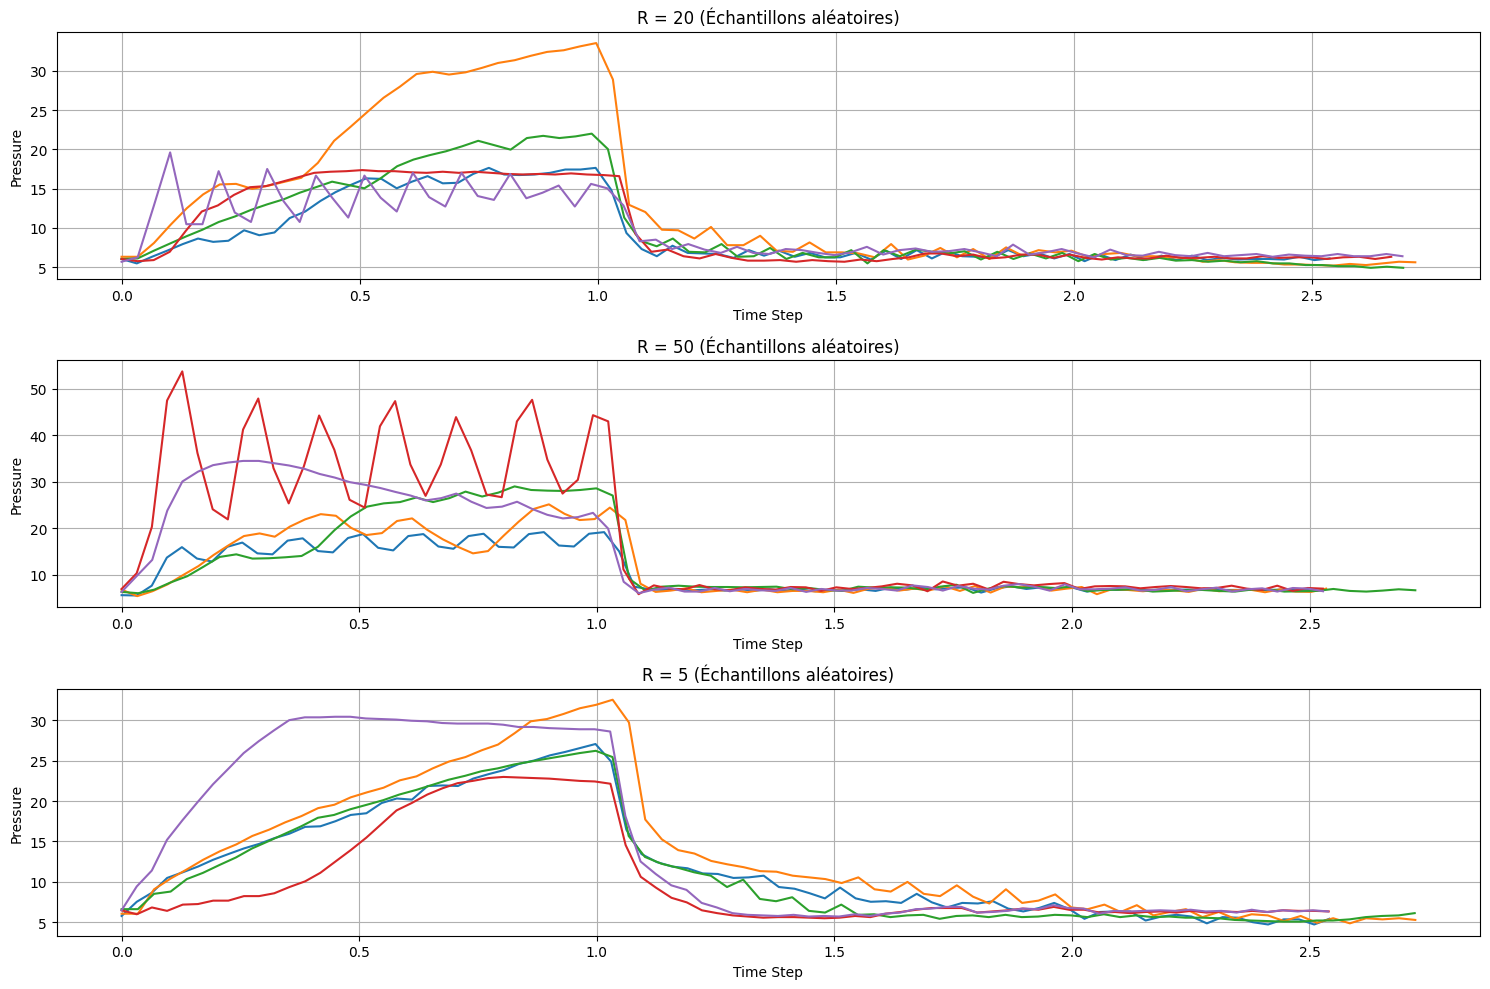

In [12]:
 # Créer une instance du visualiseur
visualizer = VentilatorVisualizer(logger, output_dir='../output')

# Visualiser les séries temporelles par caractéristique (R)
visualizer.plot_time_series_by_feature(train_df, 'R')

### Visualization by feature C

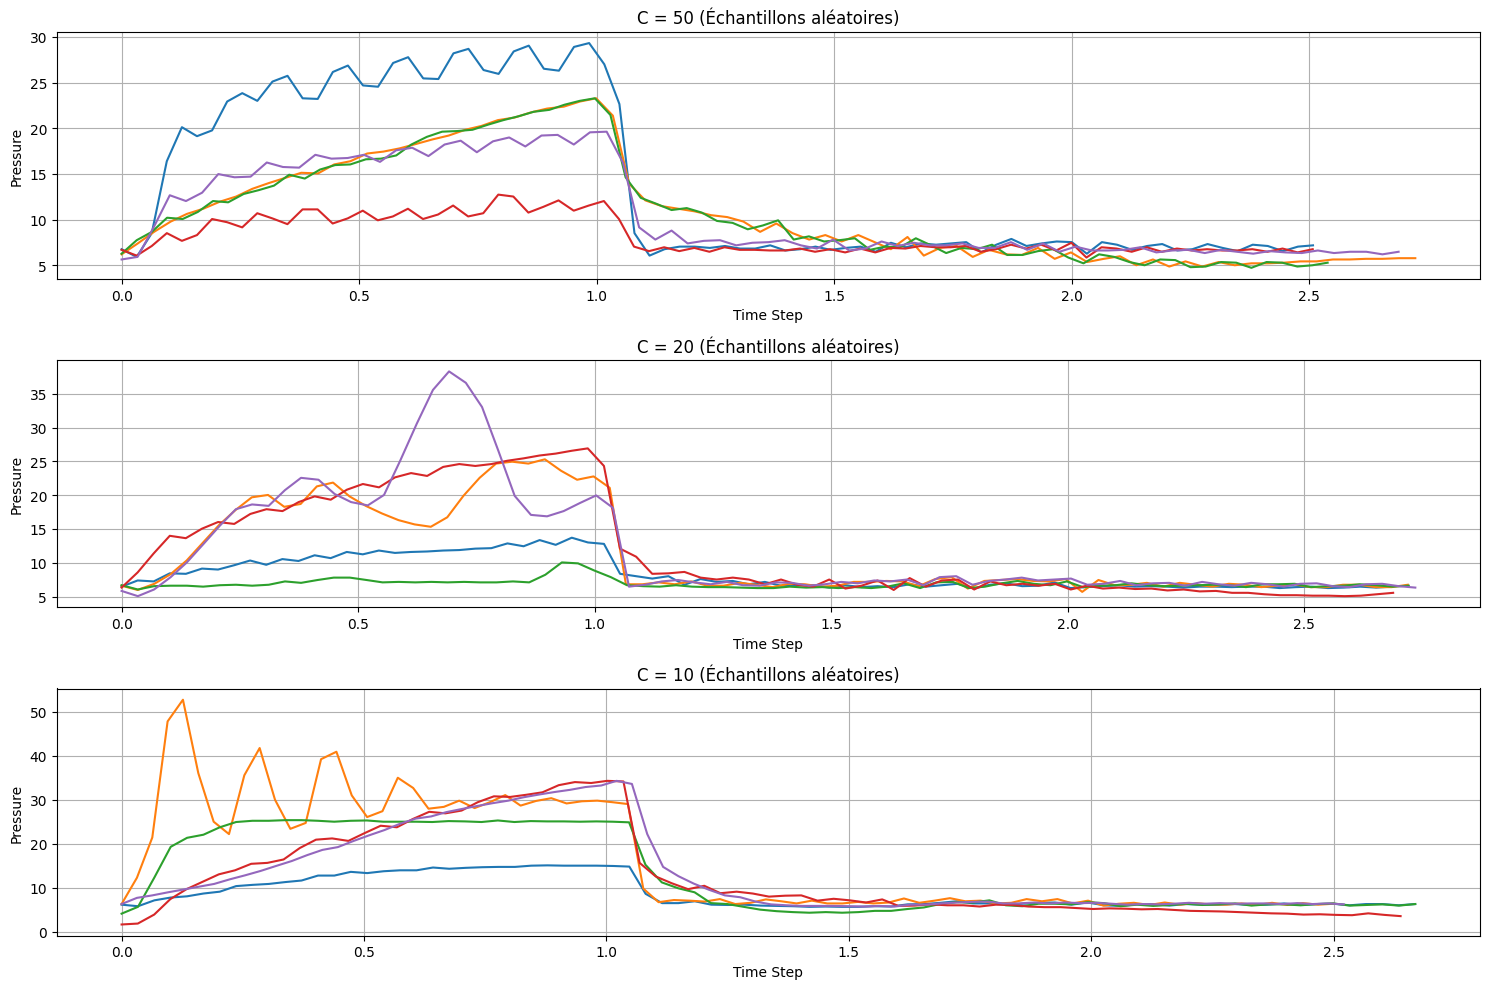

In [13]:
# Visualiser les séries temporelles par caractéristique (C)
visualizer.plot_time_series_by_feature(train_df, 'C')

### Visualization of in-out signals entries

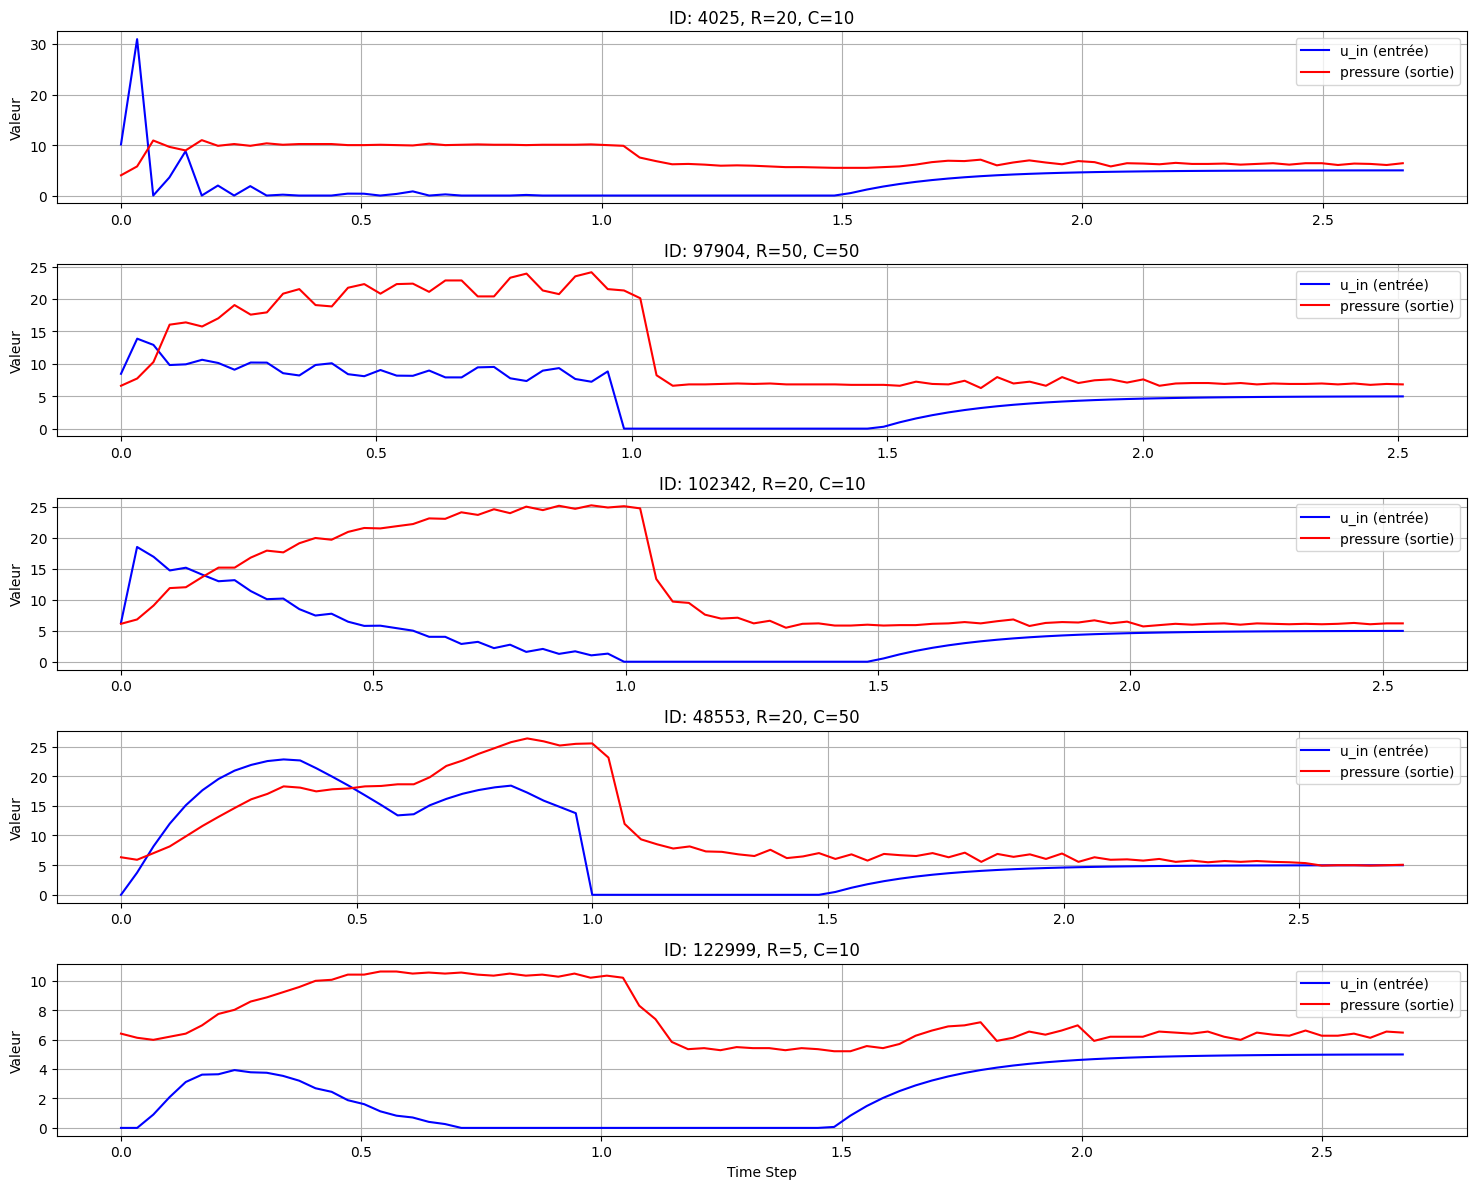

In [14]:
# Visualiser les signaux d'entrée et de sortie
visualizer.plot_input_output_signals(train_df)

### Breathing phases visulization without considering u_out

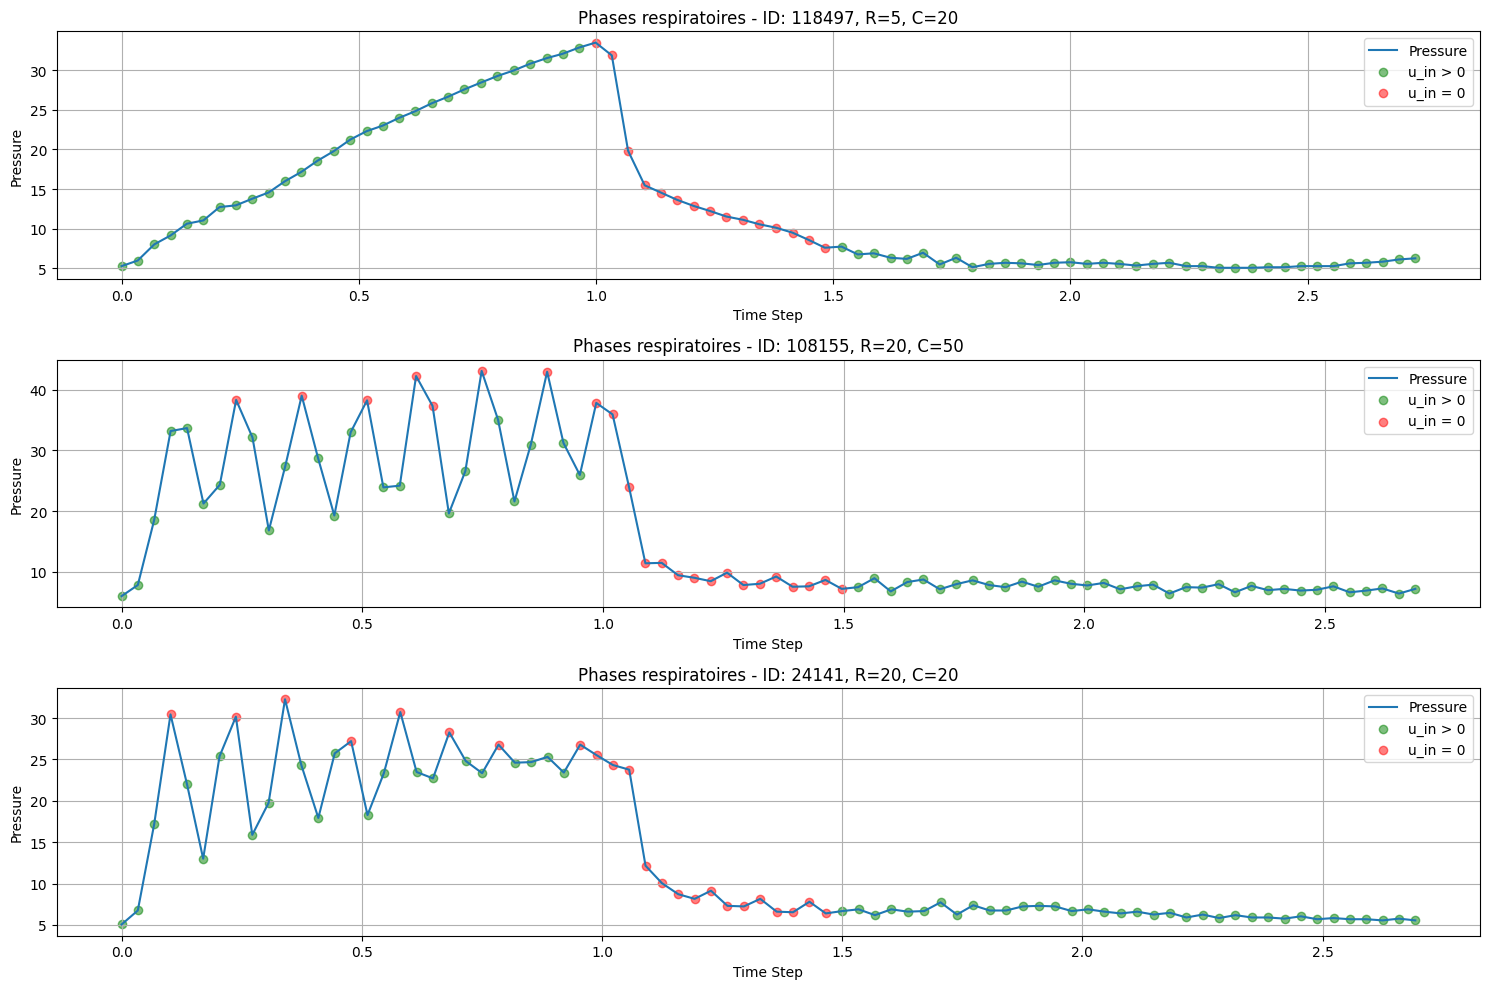

In [15]:
# Visualiser les phases de respiration
visualizer.plot_breathing_phases(train_df)

### Breathing phases visualization with u_out

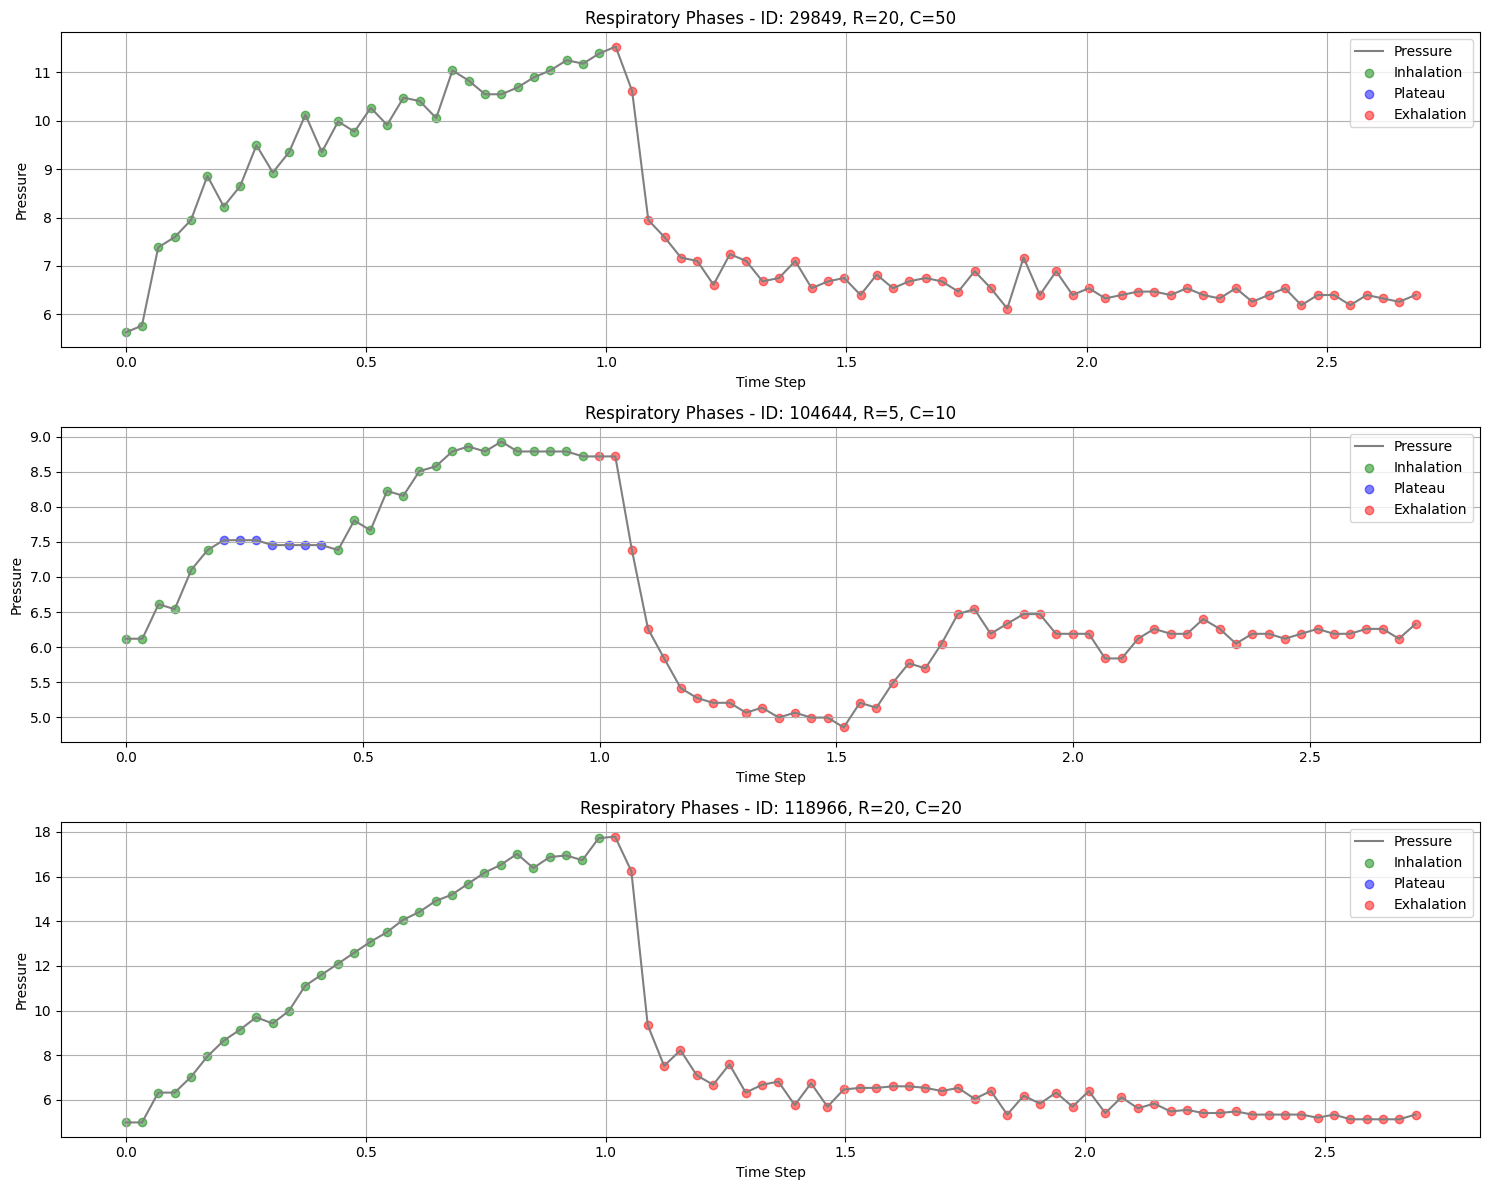

In [16]:
# Visualiser les phases de respiration
visualizer.plot_breathing_phases_with_uout(train_df)

## 1.4 Correlation Matrix and relationship analysis

### Correlation matrix between aggregate features

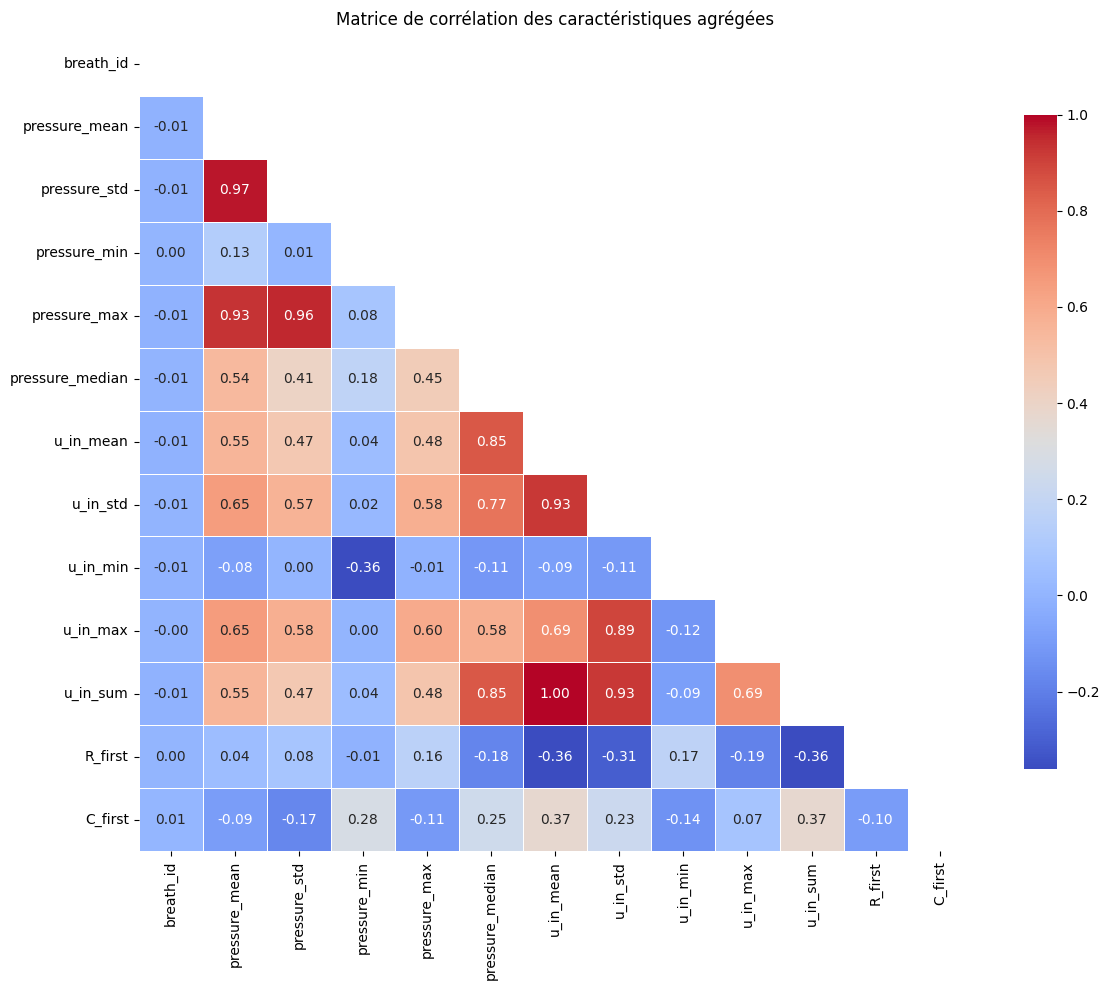

In [17]:
# Suppression de la colonne id
train_df.drop('id', axis=1, inplace=True)

# Agréger les caractéristiques pour l'analyse
agg_train = preprocessor.aggregate_features(train_df)

# Visualiser la matrice de corrélation
visualizer.plot_correlation_matrix(agg_train, title="Matrice de corrélation des caractéristiques agrégées")

### Correlation matrix between original features

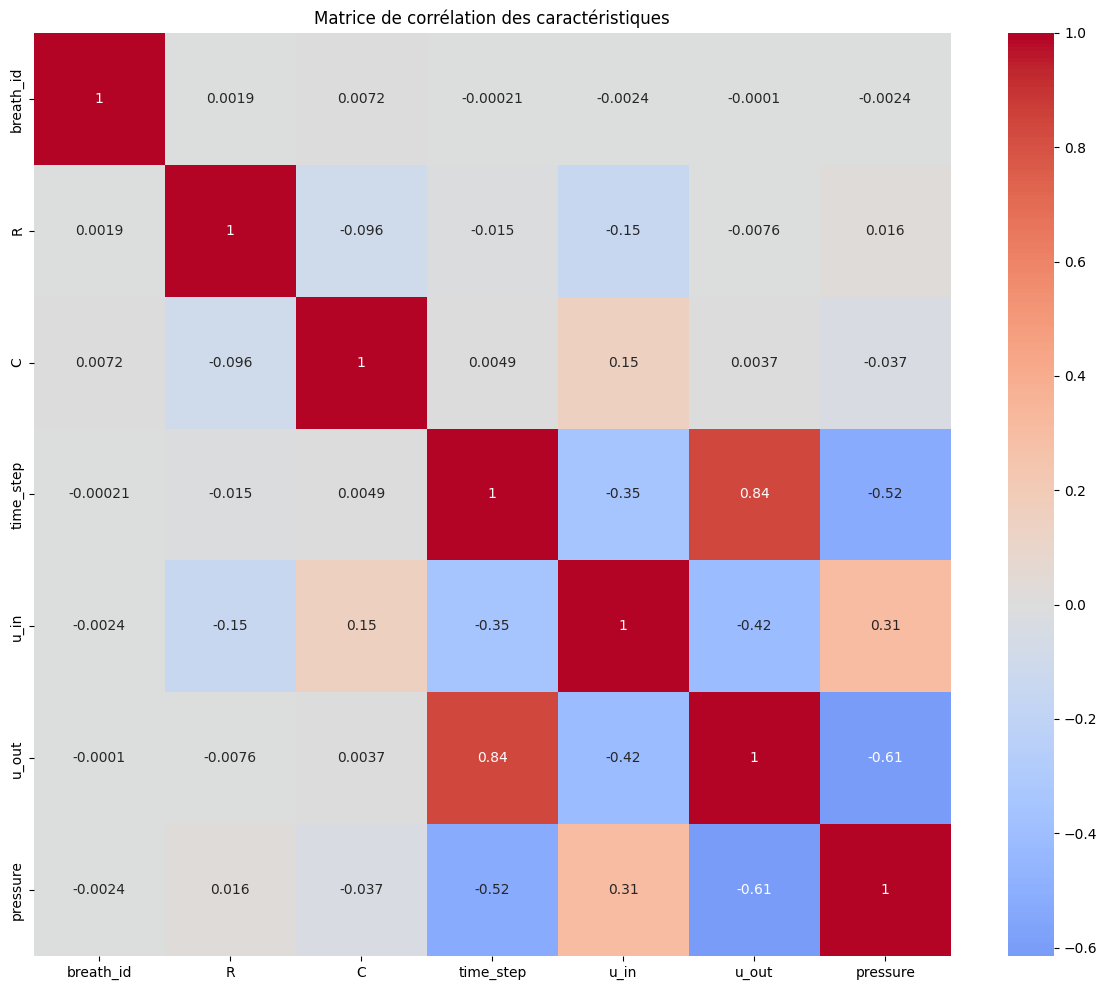

In [18]:
# Visualiser la matrice de corrélation
visualizer.plot_correlation_matrix_pearson(train_df, title="Matrice de corrélation des caractéristiques")

### Features relationship analysis

#### Features relationship analysis on aggregate data

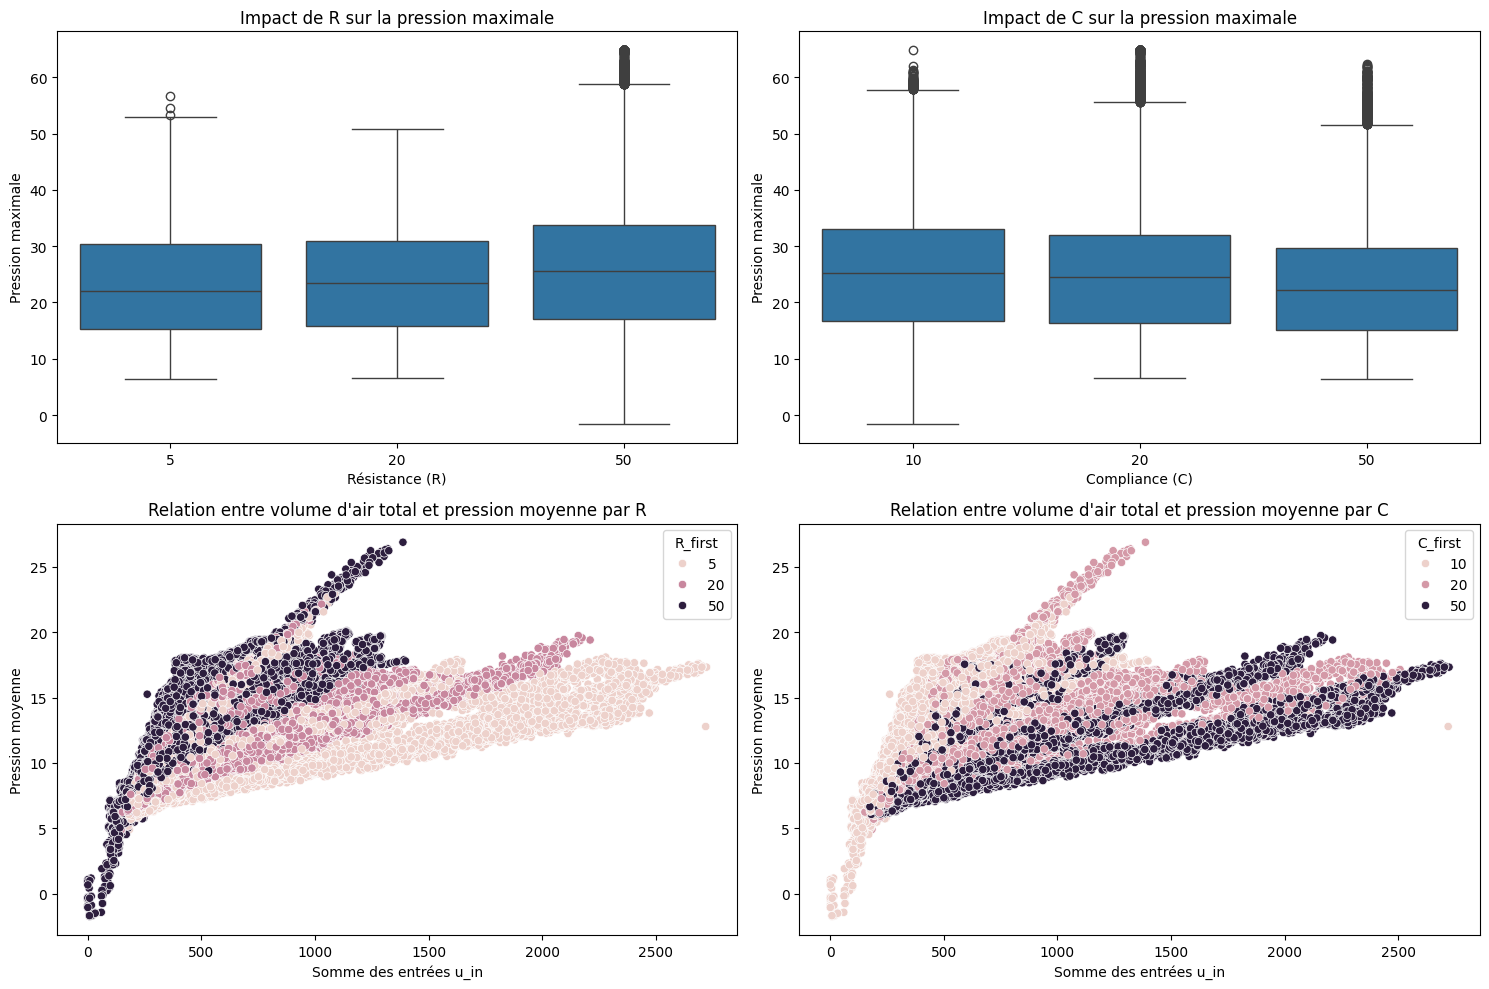

In [19]:
# Visualiser les relations entre caractéristiques
visualizer.plot_feature_relationships(agg_train)

#### Features releationship analysis on raw data

In [20]:
# Visualiser les relations entre caractéristiques sur données brutes
# visualizer.plot_feature_relationships_raw(train_df)

#### Features relationship analysis when u_out = 1 (exploratory solenoid valve is closed)

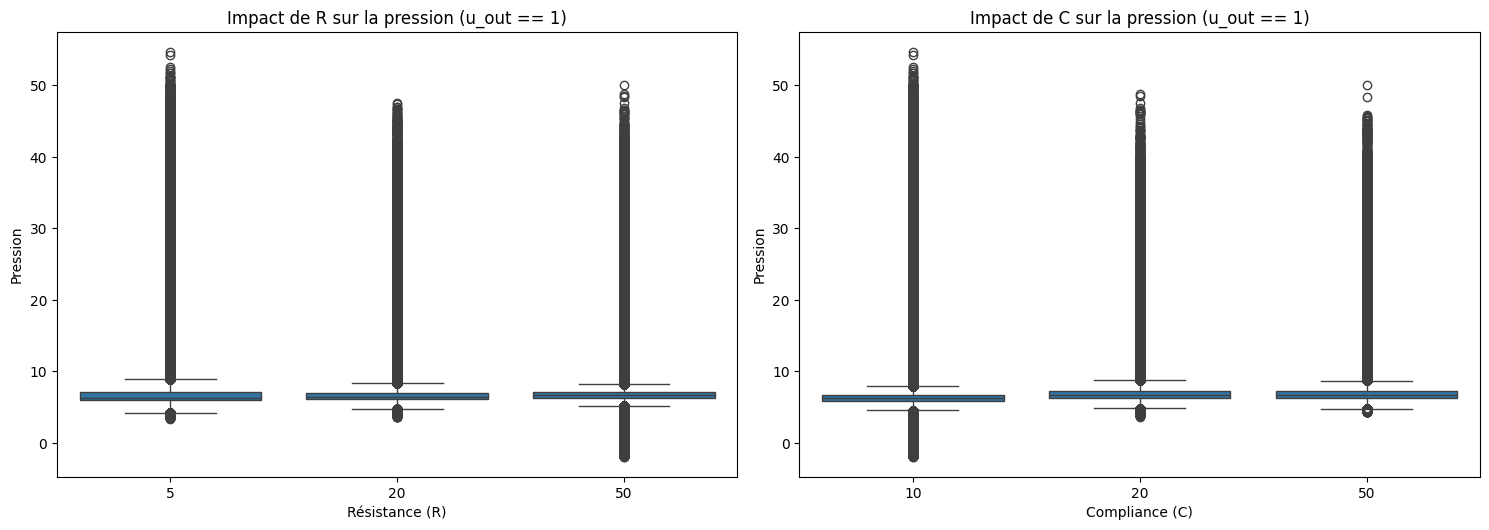

In [21]:
# Visualiser les relations entre caractéristiques sur données brutes
visualizer.plot_feature_relationships_filtered(train_df)

## 1.5 Dimensionality Reduction with t-SNE and UMAP

In [22]:
# Préparer les données pour la réduction de dimension
sequences, labels_r, labels_c = preprocessor.prepare_data_for_dim_reduction(train_df, sample_size=1000)

Préparation des données pour réduction de dimension: 100%|██████████| 1000/1000 [00:03<00:00, 322.66it/s]


In [23]:
from sklearn.manifold import TSNE
import umap
import numpy as np
from tqdm import tqdm

class DimensionalityReducer:
    """
    Classe pour réduire la dimensionnalité des données
    """

    def __init__(self):
        """
        Initialise le réducteur de dimensionnalité
        """
        pass

    def apply_tsne(self, sequences, random_state=42, perplexity=30):
        """
        Applique t-SNE pour réduire la dimensionnalité

        Args:
            sequences: Séquences de données à réduire
            random_state: État aléatoire pour reproduire les résultats
            perplexity: Paramètre de perplexité pour t-SNE

        Returns:
            numpy.ndarray: Résultats de t-SNE en 2D
        """
        print("Exécution de t-SNE...")
        tsne = TSNE(n_components=2, random_state=random_state, perplexity=perplexity)
        return tsne.fit_transform(sequences)

    def apply_umap(self, sequences, n_neighbors=30, random_state=42):
        """
        Applique UMAP pour réduire la dimensionnalité

        Args:
            sequences: Séquences de données à réduire
            random_state: État aléatoire pour reproduire les résultats

        Returns:
            numpy.ndarray: Résultats de UMAP en 2D
        """
        print("Exécution de UMAP...")
        reducer = umap.UMAP(n_neighbors, random_state=random_state)
        return reducer.fit_transform(sequences)

### t-SNE Algorithm

Exécution de t-SNE...


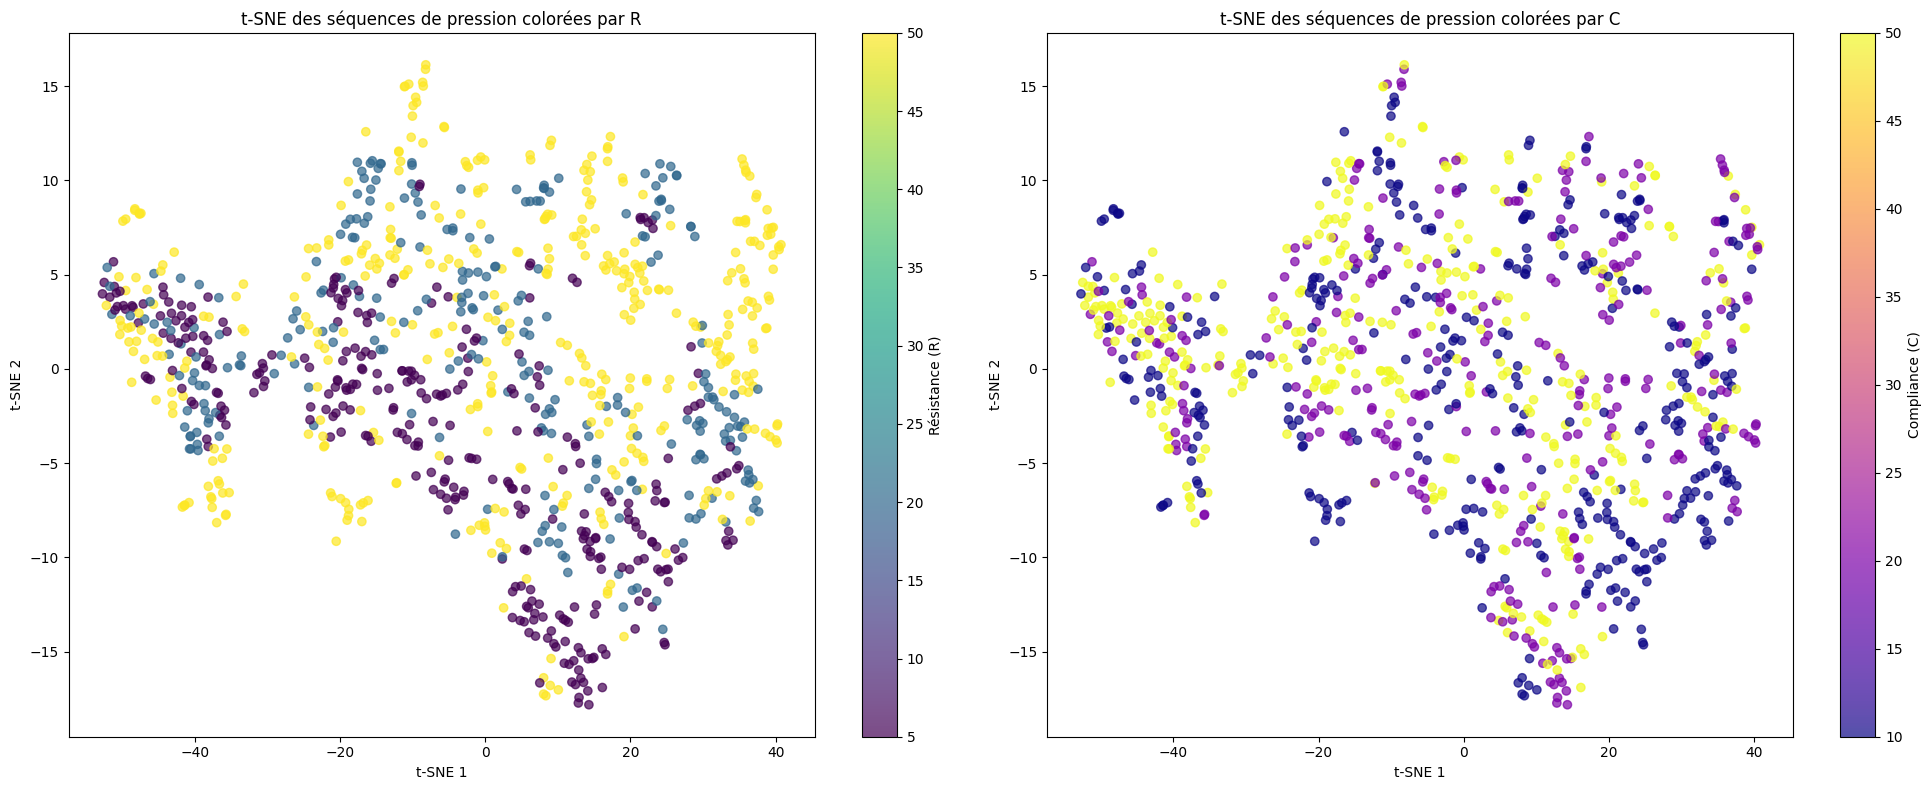

In [24]:
# Créer une instance du réducteur de dimensionnalité
dim_reducer = DimensionalityReducer()

# Appliquer t-SNE
tsne_results = dim_reducer.apply_tsne(sequences, random_state=42, perplexity=50)

# Visualiser les résultats t-SNE
visualizer.plot_dim_reduction(tsne_results, labels_r, labels_c, method='t-SNE')

### UMAP Algorithm

Exécution de UMAP...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


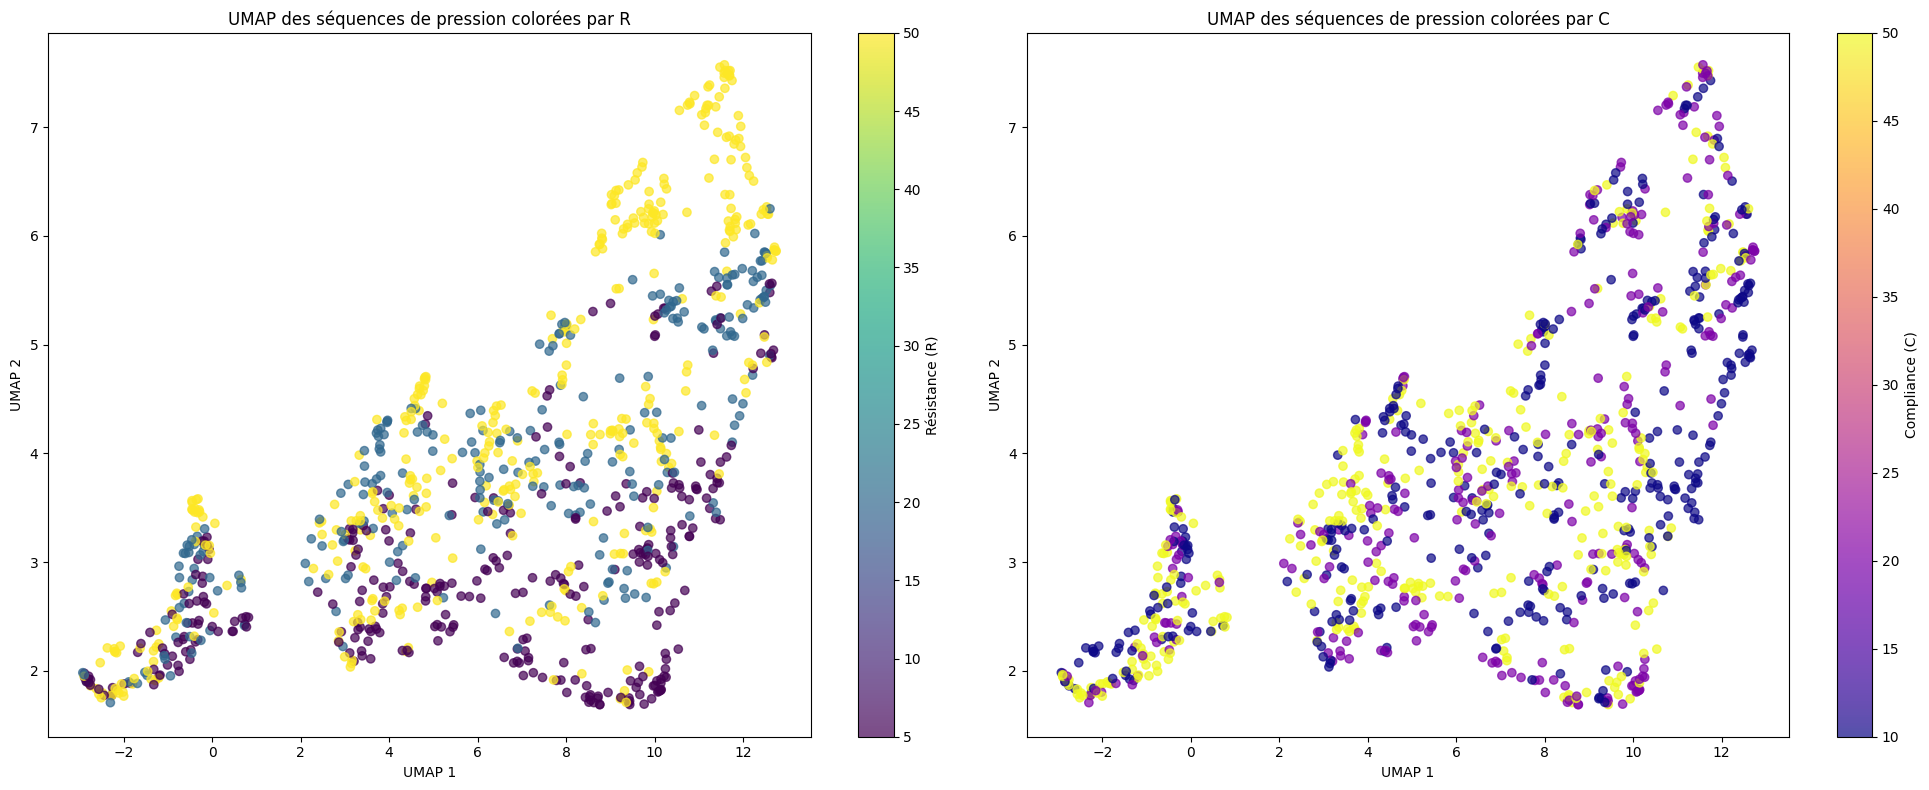

In [25]:
# Appliquer UMAP
umap_results = dim_reducer.apply_umap(sequences, n_neighbors=30, random_state=42)

# Visualiser les résultats UMAP
visualizer.plot_dim_reduction(umap_results, labels_r, labels_c, method='UMAP')

In [26]:
logger.finish()

## 1.6 Documentation des insights découverts

In [27]:
class InsightsGenerator:
    """
    Classe pour générer et sauvegarder les insights découverts lors de l'EDA
    """

    def __init__(self, output_file='insights_analysis.md'):
        """
        Initialise le générateur d'insights

        Args:
            output_file: Fichier où sauvegarder les insights
        """
        self.output_file = output_file

    def generate_insights(self):
        """
        Génère un document d'insights basé sur l'analyse des données

        Returns:
            str: Le contenu des insights générés
        """
        insights = """
        # Insights clés de l'analyse exploratoire des données - Ventilator Pressure Prediction

        ## Structure des données
        - Les données représentent des séries temporelles de respiration artificielle avec 80 pas de temps par cycle respiratoire.
        - Variables principales: u_in (débit d'entrée), pressure (pression à prédire), R (résistance) et C (compliance).
        - Chaque cycle respiratoire a une phase d'inspiration (u_in > 0) suivie d'une phase d'expiration (u_in = 0).

        ## Relations et comportements physiques
        1. **Impact de R et C sur la pression**:
        - Une résistance (R) plus élevée entraîne une augmentation plus lente de la pression pendant l'inspiration.
        - Une compliance (C) plus élevée est associée à des pressions maximales plus faibles pour un même volume d'air.

        2. **Dynamique temporelle**:
        - La phase d'expiration montre un comportement de décroissance exponentielle caractéristique.
        - Les dérivées de pression mettent en évidence les transitions entre inspiration et expiration.

        3. **Caractéristiques dérivées importantes**:
        - Le volume d'air cumulatif (cumsum de u_in) est fortement corrélé avec la pression maximale.
        - La variabilité des dérivées (écart-type) peut être un indicateur important des propriétés physiques.

        ## Insights de réduction dimensionnelle
        - Les visualisations t-SNE et UMAP montrent une séparation claire des cycles respiratoires en fonction de R et C.
        - Les cycles avec des valeurs similaires de R et C ont tendance à se regrouper, confirmant que ces paramètres définissent largement le comportement du système.
        - Les paramètres de t-SNE et UMAP sont en cours d'amélioration pour obtenir une stabilité

        2. **Stratégies de modélisation recommandées**:
        - Préparer les data loader
        - Réseaux de neurones récurrents (LSTM/GRU) pour capturer les dépendances temporelles.
        - Modèles basés sur les transformers pour modéliser les séquences complètes.
        - Features d'ingénierie incluant: u_in cumulatif, dérivées de pression, statistiques glissantes.
        """

        # Enregistrer les insights dans un fichier
        with open('insights_analysis.md', 'w') as f:
            f.write(insights)

        print("Analyse exploratoire des données terminée. Les résultats sont enregistrés sous forme de graphiques et d'un document d'insights.")

In [28]:
# Créer une instance du générateur d'insights
insights_generator = InsightsGenerator(output_file='../output/insights_analysis.md')

# Générer et sauvegarder les insights
insights = insights_generator.generate_insights()

# Afficher les insights
print(insights)

Analyse exploratoire des données terminée. Les résultats sont enregistrés sous forme de graphiques et d'un document d'insights.
None


# Feature Engineering - Google Brain Ventilator Pressure Prediction
This notebook provides a complete feature engineering phase for the Kaggle project “Google Brain - Ventilator Pressure Prediction

In [29]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from typing import Tuple, List, Optional
import warnings
warnings.filterwarnings('ignore')

class VentilatorPreprocessor:
    """
    Classe complète pour le preprocessing des données de ventilateur
    """

    def __init__(self):
        self.label_encoders = {}
        self.scalers = {}
        self.feature_columns = None
        self.target_column = 'pressure'

    def encode_categorical_features(self, train_df: pd.DataFrame, test_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Encode les variables catégorielles R et C avec LabelEncoding

        Args:
            train_df: DataFrame d'entraînement
            test_df: DataFrame de test

        Returns:
            Tuple des DataFrames encodés (train, test)
        """
        print("Encoding des variables catégorielles...")

        train_encoded = train_df.copy()
        test_encoded = test_df.copy()

        categorical_features = ['R', 'C']

        for feature in categorical_features:
            print(f"Encoding {feature}...")
            print(f"Valeurs uniques dans train: {sorted(train_df[feature].unique())}")
            print(f"Valeurs uniques dans test: {sorted(test_df[feature].unique())}")

            # Créer et ajuster l'encodeur sur les données d'entraînement
            le = LabelEncoder()
            le.fit(train_df[feature])
            self.label_encoders[feature] = le

            # Appliquer l'encoding
            train_encoded[feature] = le.transform(train_df[feature])
            test_encoded[feature] = le.transform(test_df[feature])

            print(f"Valeurs encodées {feature}: {sorted(train_encoded[feature].unique())}")

        return train_encoded, test_encoded

    def encode_categorical_features_oh(self, train_df: pd.DataFrame, test_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Encode les variables catégorielles R et C avec One-Hot Encoding.

        Args:
            train_df: DataFrame d'entraînement
            test_df: DataFrame de test

        Returns:
            Tuple des DataFrames encodés (train, test)
        """
        print("One-Hot Encoding des variables catégorielles...")

        categorical_features = ['R', 'C']

        # On concatène pour éviter des colonnes manquantes dans test
        combined_df = pd.concat([train_df, test_df], axis=0)

        # One-hot encoding
        combined_encoded = pd.get_dummies(combined_df, columns=categorical_features, drop_first=False)

        # Séparer à nouveau
        train_encoded = combined_encoded.iloc[:len(train_df)].reset_index(drop=True)
        test_encoded = combined_encoded.iloc[len(train_df):].reset_index(drop=True)

        print(f"Colonnes après encoding: {train_encoded.columns.tolist()}")

        return train_encoded, test_encoded

    def create_additional_features(self, df: pd.DataFrame) -> pd.DataFrame:
        print("Création de features supplémentaires...")
        df_enhanced = df.copy()

        # Normalisation du time_step par breath
        max_time = df.groupby('breath_id')['time_step'].transform('max')
        df_enhanced['time_step_norm'] = df['time_step'] / max_time
        df_enhanced['time_step_squared'] = df_enhanced['time_step_norm'] ** 2

        # u_in cumsum
        df_enhanced['u_in_cumsum'] = df.groupby('breath_id')['u_in'].cumsum()

        # u_in lag1, lag2
        df_enhanced['u_in_lag1'] = df.groupby('breath_id')['u_in'].shift(1).fillna(0)
        df_enhanced['u_in_lag2'] = df.groupby('breath_id')['u_in'].shift(2).fillna(0)

        # Interaction avec one-hot
        for r_col in [col for col in df.columns if col.startswith('R_')]:
            df_enhanced[f'u_in_x_{r_col}'] = df['u_in'] * df[r_col]

        for c_col in [col for col in df.columns if col.startswith('C_')]:
            df_enhanced[f'u_in_x_{c_col}'] = df['u_in'] * df[c_col]

        for r_col in [col for col in df.columns if col.startswith('R_')]:
            for c_col in [col for col in df.columns if col.startswith('C_')]:
                df_enhanced[f'{r_col}_x_{c_col}'] = df[r_col] * df[c_col]

        # pressure lag si colonne présente
        if 'pressure' in df.columns:
            df_enhanced['pressure_lag1'] = df.groupby('breath_id')['pressure'].shift(1).fillna(0)
            df_enhanced['pressure_lag2'] = df.groupby('breath_id')['pressure'].shift(2).fillna(0)
        else:
            df_enhanced['pressure_lag1'] = 0
            df_enhanced['pressure_lag2'] = 0

        print(f"Features créées. Shape: {df_enhanced.shape}")
        return df_enhanced


    """ def create_additional_features(self, df: pd.DataFrame) -> pd.DataFrame:
        print("Création de features supplémentaires...")

        df_enhanced = df.copy()

        # Normalisation du time_step par breath
        max_time = df.groupby('breath_id')['time_step'].transform('max')
        df_enhanced['time_step_norm'] = df['time_step'] / max_time
        df_enhanced['time_step_squared'] = df_enhanced['time_step_norm'] ** 2

        # u_in cumsum
        df_enhanced['u_in_cumsum'] = df.groupby('breath_id')['u_in'].cumsum()

        # u_in lag1, lag2
        df_enhanced['u_in_lag1'] = df.groupby('breath_id')['u_in'].shift(1).fillna(0)
        df_enhanced['u_in_lag2'] = df.groupby('breath_id')['u_in'].shift(2).fillna(0)

        # interaction terms
        df_enhanced['u_in_x_R'] = df['u_in'] * df['R']
        df_enhanced['u_in_x_C'] = df['u_in'] * df['C']
        df_enhanced['RC_interaction'] = df['R'] * df['C']

        # pressure lag si colonne présente
        if 'pressure' in df.columns:
            df_enhanced['pressure_lag1'] = df.groupby('breath_id')['pressure'].shift(1).fillna(0)
            df_enhanced['pressure_lag2'] = df.groupby('breath_id')['pressure'].shift(2).fillna(0)
        else:
            df_enhanced['pressure_lag1'] = 0
            df_enhanced['pressure_lag2'] = 0


        print(f"Features créées. Shape: {df_enhanced.shape}")
        return df_enhanced """


    def normalize_features(self, train_df: pd.DataFrame, test_df: pd.DataFrame,
                          method: str = 'standard') -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Normalise les features numériques

        Args:
            train_df: DataFrame d'entraînement
            test_df: DataFrame de test
            method: 'standard' ou 'minmax'

        Returns:
            Tuple des DataFrames normalisés (train, test)
        """
        print(f"Normalisation des features avec {method} scaling...")

        train_normalized = train_df.copy()
        test_normalized = test_df.copy()

        # Features à normaliser (exclure les identifiants et target)
        exclude_cols = ['id', 'breath_id', 'u_out', 'R', 'C','pressure'] if 'pressure' in train_df.columns else ['id', 'breath_id']
        numeric_features = [col for col in train_df.select_dtypes(include=[np.number]).columns
                           if col not in exclude_cols]
        one_hot_cols = [col for col in train_df.columns if col.startswith('R_') or col.startswith('C_')]
        exclude_cols += one_hot_cols

        self.feature_columns = numeric_features
        print(f"Features à normaliser: {numeric_features}")

        # Choisir le scaler
        if method == 'standard':
            scaler = StandardScaler()
        elif method == 'minmax':
            scaler = MinMaxScaler()
        else:
            raise ValueError("method doit être 'standard' ou 'minmax'")

        # Ajuster le scaler sur les données d'entraînement
        scaler.fit(train_df[numeric_features])
        self.scalers['features'] = scaler

        # Appliquer la normalisation
        train_normalized[numeric_features] = scaler.transform(train_df[numeric_features])
        test_normalized[numeric_features] = scaler.transform(test_df[numeric_features])

        # Inclure u_out + one hot dans les features finales
        self.feature_columns = numeric_features + ['u_out'] + one_hot_cols

        print("Normalisation terminée.")
        return train_normalized, test_normalized

    def split_train_validation(self, train_df: pd.DataFrame, val_size: float = 0.2,
                              random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Divise les données d'entraînement en train/validation par breath_id

        Args:
            train_df: DataFrame d'entraînement complet
            val_size: Proportion pour la validation
            random_state: Seed pour la reproductibilité

        Returns:
            Tuple (train_split, val_split)
        """
        print(f"Division train/validation ({1-val_size:.1%}/{val_size:.1%})...")

        # Obtenir les breath_ids uniques
        unique_breath_ids = train_df['breath_id'].unique()

        # Diviser les breath_ids
        train_breath_ids, val_breath_ids = train_test_split(
            unique_breath_ids,
            test_size=val_size,
            random_state=random_state
        )

        # Créer les splits
        train_split = train_df[train_df['breath_id'].isin(train_breath_ids)].copy()
        val_split = train_df[train_df['breath_id'].isin(val_breath_ids)].copy()

        print(f"Train: {len(train_breath_ids)} breath_ids, {len(train_split)} samples")
        print(f"Validation: {len(val_breath_ids)} breath_ids, {len(val_split)} samples")

        return train_split, val_split

In [30]:
class VentilatorTimeSeriesDataset(Dataset):
    def __init__(self, df: pd.DataFrame, window_size: int = 20,
                 feature_columns: List[str] = None, target_column: str = 'pressure',
                 n_future_steps: int = 1, stride: int = 1,
                 prediction_mode: bool = False):
        """
        Dataset PyTorch optimisé pour time series ventilator

        Args:
            df: DataFrame avec les données
            window_size: Taille des fenêtres
            feature_columns: Colonnes de features
            target_column: Nom de la colonne target
            n_future_steps: Nombre de pas futurs à prédire
            stride: Décalage entre les fenêtres
            prediction_mode: Mode test sans target
        """
        self.df = df.copy()
        self.window_size = window_size
        self.feature_columns = feature_columns
        self.target_column = target_column
        self.n_future_steps = n_future_steps
        self.stride = stride
        self.prediction_mode = prediction_mode

        # Grouper et indexer
        self.breath_groups = dict(tuple(self.df.groupby('breath_id')))

        # Calculer les indices des fenêtres (breath_id, start_idx)
        self.indices = []
        for breath_id, data in self.breath_groups.items():
            n_rows = len(data)
            for i in range(0, n_rows - window_size - n_future_steps + 1, stride):
                self.indices.append((breath_id, i))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        breath_id, start_idx = self.indices[idx]
        data = self.breath_groups[breath_id]

        window = data.iloc[start_idx : start_idx + self.window_size]
        features = window[self.feature_columns].values.astype(np.float32)

        result = {
            'features': torch.tensor(features, dtype=torch.float32),
            'breath_id': breath_id,
            'start_idx': start_idx
        }

        if not self.prediction_mode:
            target_window = data.iloc[start_idx + self.window_size : start_idx + self.window_size + self.n_future_steps]
            target = target_window[self.target_column].values.astype(np.float32)
            if self.n_future_steps == 1:
                target = target[0]  # Scalar si un seul step
            result['target'] = torch.tensor(target, dtype=torch.float32)

        return result


In [31]:
class VentilatorDataModule:
    """
    Module pour gérer tous les aspects des données
    """

    def __init__(self, train_df: pd.DataFrame, test_df: pd.DataFrame,
                 window_size: int = 10, batch_size: int = 32,
                 val_size: float = 0.2, num_workers: int = 4):
        """
        Initialise le module de données

        Args:
            train_df: DataFrame d'entraînement brut
            test_df: DataFrame de test brut
            window_size: Taille de la fenêtre glissante
            batch_size: Taille des batches
            val_size: Proportion pour la validation
            num_workers: Nombre de workers pour le DataLoader
        """
        self.train_df_raw = train_df
        self.test_df_raw = test_df
        self.window_size = window_size
        self.batch_size = batch_size
        self.val_size = val_size
        self.num_workers = num_workers

        self.preprocessor = VentilatorPreprocessor()
        self.train_df_processed = None
        self.test_df_processed = None
        self.train_split = None
        self.val_split = None

    def prepare_data(self, normalization_method: str = 'standard'):
        """
        Prépare toutes les données (encoding, features, normalisation, split)

        Args:
            normalization_method: 'standard' ou 'minmax'
        """
        print("=== PRÉPARATION DES DONNÉES ===")

        # Encoding des variables catégorielles
        train_encoded, test_encoded = self.preprocessor.encode_categorical_features_oh(
            self.train_df_raw, self.test_df_raw
        )

        # Création de features supplémentaires
        #train_enhanced = self.preprocessor.create_additional_features(train_encoded)
        #test_enhanced = self.preprocessor.create_additional_features(test_encoded)

        train_enhanced = train_encoded
        test_enhanced = test_encoded

        # Normalisation
        self.train_df_processed, self.test_df_processed = self.preprocessor.normalize_features(
            train_enhanced, test_enhanced, method=normalization_method
        )

        # Split train/validation
        self.train_split, self.val_split = self.preprocessor.split_train_validation(
            self.train_df_processed, val_size=self.val_size
        )

        print("Préparation des données terminée !")
        print(f"Features utilisées: {len(self.preprocessor.feature_columns)} features")
        print(f"Train shape: {self.train_split.shape}")
        print(f"Validation shape: {self.val_split.shape}")
        print(f"Test shape: {self.test_df_processed.shape}")

    def get_datasets(self) -> Tuple[VentilatorTimeSeriesDataset, VentilatorTimeSeriesDataset, VentilatorTimeSeriesDataset]:
        """
        Crée les datasets PyTorch

        Returns:
            Tuple (train_dataset, val_dataset, test_dataset)
        """
        if self.train_df_processed is None:
            raise ValueError("Les données doivent être préparées avant de créer les datasets. Appelez prepare_data() d'abord.")

        print("Création des datasets PyTorch...")

        train_dataset = VentilatorTimeSeriesDataset(
            self.train_split,
            window_size=self.window_size,
            feature_columns=self.preprocessor.feature_columns,
            prediction_mode=False
        )

        val_dataset = VentilatorTimeSeriesDataset(
            self.val_split,
            window_size=self.window_size,
            feature_columns=self.preprocessor.feature_columns,
            prediction_mode=False
        )

        test_dataset = VentilatorTimeSeriesDataset(
            self.test_df_processed,
            window_size=self.window_size,
            feature_columns=self.preprocessor.feature_columns,
            prediction_mode=True
        )

        print(f"Train dataset: {len(train_dataset)} windows")
        print(f"Validation dataset: {len(val_dataset)} windows")
        print(f"Test dataset: {len(test_dataset)} windows")

        return train_dataset, val_dataset, test_dataset

    def get_dataloaders(self) -> Tuple[DataLoader, DataLoader, DataLoader]:
        """
        Crée les DataLoaders PyTorch

        Returns:
            Tuple (train_loader, val_loader, test_loader)
        """
        train_dataset, val_dataset, test_dataset = self.get_datasets()

        print("Création des DataLoaders...")

        train_loader = DataLoader(
            train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True
        )

        print(f"Train loader: {len(train_loader)} batches")
        print(f"Validation loader: {len(val_loader)} batches")
        print(f"Test loader: {len(test_loader)} batches")

        return train_loader, val_loader, test_loader

## 2.1 Full preprocessing

In [32]:
#Testing the full preprocessing
def testing_preprocessing(train_df, test_df):
    print("=== TEST OF PREPROCESSING ===")

    # Créer le module de données
    data_module = VentilatorDataModule(
        train_df=train_df,
        test_df=test_df,
        window_size=15,
        batch_size=64,
        val_size=0.2,
        num_workers=-1
    )

    # Préparer les données
    data_module.prepare_data(normalization_method='minmax')

    # Obtenir les DataLoaders
    train_loader, val_loader, test_loader = data_module.get_dataloaders()

    # Tester un batch
    print("\n=== TEST D'UN BATCH ===")
    for batch_idx, batch in enumerate(train_loader):
        print(f"Batch {batch_idx + 1}:")
        print(f"  Features shape: {batch['features'].shape}")
        print(f"  Target shape: {batch['target'].shape}")
        print(f"  Breath IDs: {len(set(batch['breath_id']))}")

        # Afficher quelques statistiques
        print(f"  Features min/max: {batch['features'].min():.3f} / {batch['features'].max():.3f}")
        print(f"  Targets min/max: {batch['target'].min():.3f} / {batch['target'].max():.3f}")

        if batch_idx == 0:  # Juste le premier batch pour la démo
            break

    return data_module, train_loader, val_loader, test_loader

In [70]:
data_module = VentilatorDataModule(
    train_df=train_df,
    test_df=test_df,
    window_size=10,      # Fenêtre dE pas de temps
    batch_size=512,      # Taille de batch
    val_size=0.2,        # 20% pour validation
    num_workers=0        # Processus parallèles
)

In [71]:
print("\n" + "="*50)
print("DÉMARRAGE DU PREPROCESSING COMPLET")
print("="*50)

# Préparer toutes les données
data_module.prepare_data(normalization_method='minmax')

# Obtenir les DataLoaders
train_loader, val_loader, test_loader = data_module.get_dataloaders()

# ===== INSPECTION DES DONNÉES PRÉPROCESSÉES =====

print("\n" + "="*50)
print("INSPECTION DES DONNÉES PRÉPROCESSÉES")
print("="*50)

# Analyser un batch d'entraînement
sample_batch = next(iter(train_loader))
print(f"Shape des features: {sample_batch['features'].shape}")
print(f"Shape des targets: {sample_batch['target'].shape}")
print(f"Nombre de features: {sample_batch['features'].shape[-1]}")
print(f"Taille de la fenêtre: {sample_batch['features'].shape[1]}")

# Afficher les noms des features utilisées
print(f"\nFeatures utilisées ({len(data_module.preprocessor.feature_columns)}):")
for i, feature in enumerate(data_module.preprocessor.feature_columns):
    print(f"  {i+1:2d}. {feature}")

# Statistiques des encodages
print(f"\nEncodages des variables catégorielles:")
for feature, encoder in data_module.preprocessor.label_encoders.items():
    print(f"  {feature}: {dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))}")


DÉMARRAGE DU PREPROCESSING COMPLET
=== PRÉPARATION DES DONNÉES ===
One-Hot Encoding des variables catégorielles...
Colonnes après encoding: ['breath_id', 'time_step', 'u_in', 'u_out', 'pressure', 'id', 'R_5', 'R_20', 'R_50', 'C_10', 'C_20', 'C_50']
Normalisation des features avec minmax scaling...
Features à normaliser: ['time_step', 'u_in']
Normalisation terminée.
Division train/validation (80.0%/20.0%)...
Train: 60360 breath_ids, 4828800 samples
Validation: 15090 breath_ids, 1207200 samples
Préparation des données terminée !
Features utilisées: 9 features
Train shape: (4828800, 12)
Validation shape: (1207200, 12)
Test shape: (4024000, 12)
Création des datasets PyTorch...
Train dataset: 4225200 windows
Validation dataset: 1056300 windows
Test dataset: 3521000 windows
Création des DataLoaders...
Train loader: 8253 batches
Validation loader: 2064 batches
Test loader: 6877 batches

INSPECTION DES DONNÉES PRÉPROCESSÉES
Shape des features: torch.Size([512, 10, 9])
Shape des targets: torch

### 2.1.1 Visualization preprocessed data

In [35]:
logger = WandbLogger(
    project=WANDB_LOGGER_PROJECT_NAME,
    run_name="run_vis_preprocessed_data",
    group="Visualization",
    api_key=WANDB_LOGGER_API_KEY
)

def save_and_log_figure(logger: WandbLogger,fig, filename: str):
    output_dir = "output"
    os.makedirs(output_dir, exist_ok=True)
    fig_path = f"{output_dir}/{filename}.png"
    fig.savefig(fig_path)
    if logger:
        logger.log_image(fig, name=filename)
        logger.finish()

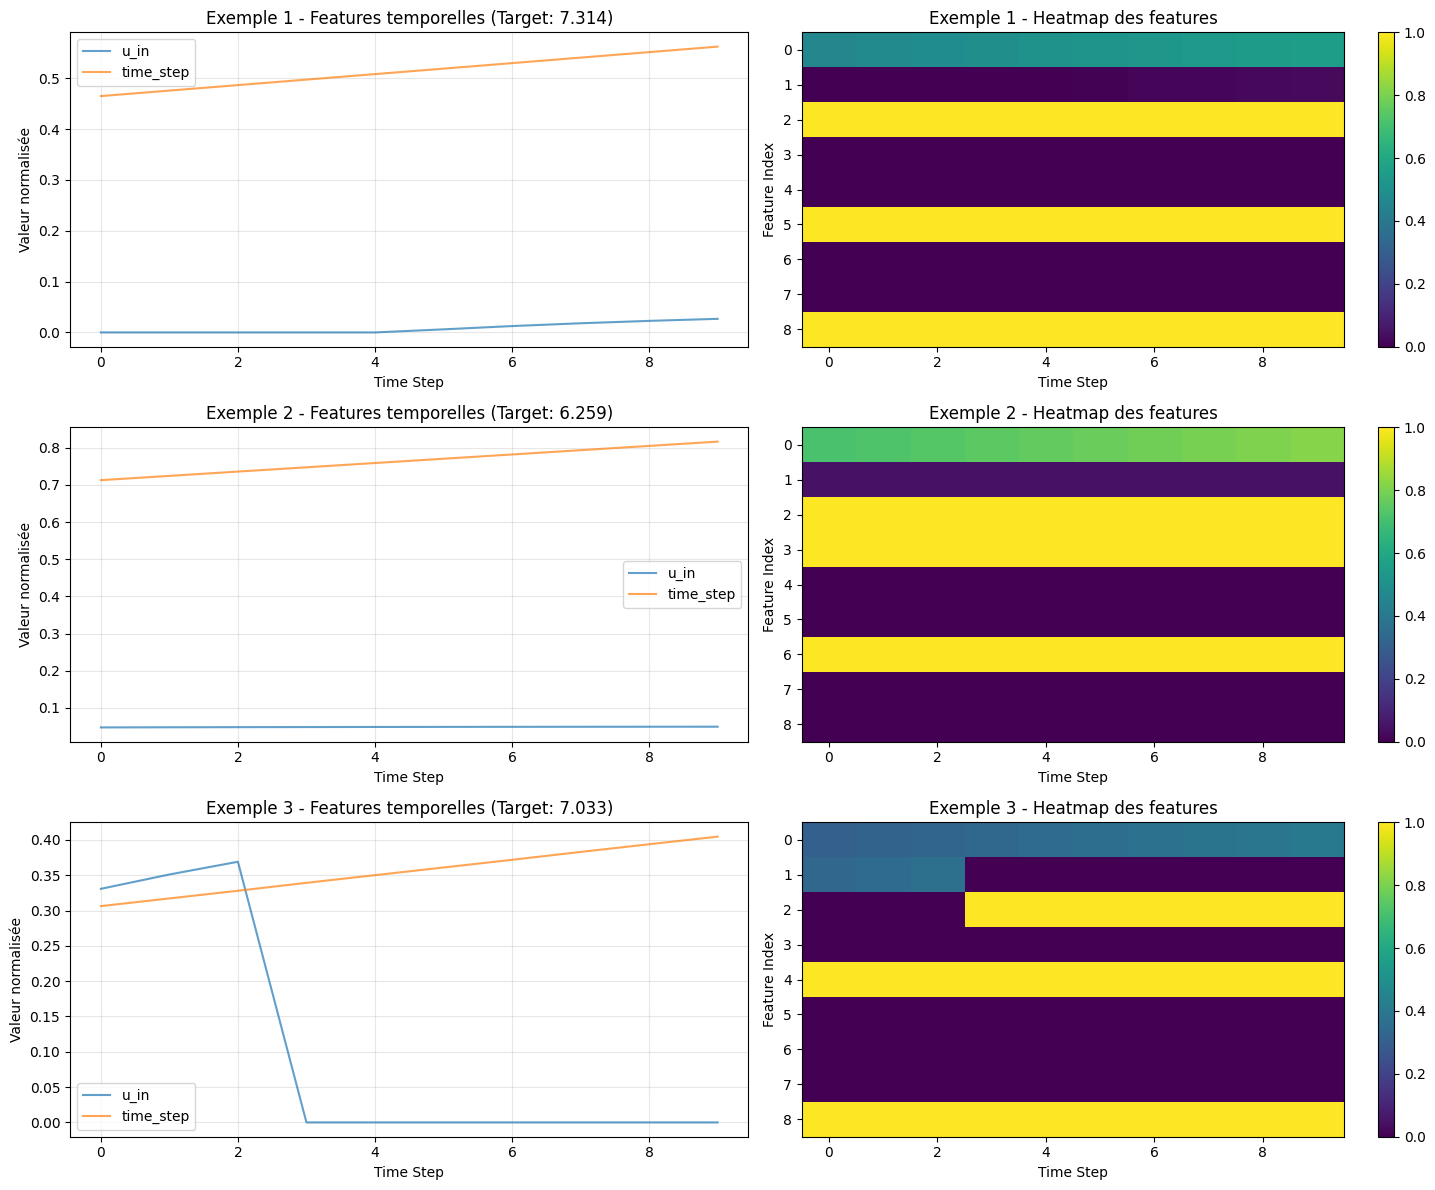

In [36]:
def visualize_preprocessed_data(data_module, train_loader):

    import matplotlib.pyplot as plt
    import numpy as np

    # Récupérer un batch pour visualisation
    batch = next(iter(train_loader))
    features = batch['features']
    targets = batch['target']

    # Sélectionner quelques exemples
    n_examples = min(3, features.shape[0])

    plt.figure(figsize=(15, 12))

    for i in range(n_examples):
        # Features temporelles pour cet exemple
        example_features = features[i].numpy()  # Shape: [window_size, num_features]
        example_target = targets[i].item()

        plt.subplot(n_examples, 2, 2*i + 1)

        # Visualiser quelques features importantes
        feature_names = data_module.preprocessor.feature_columns
        important_features = ['u_in', 'time_step', 'R', 'C', 'u_in_cumsum']

        for feat_name in important_features:
            if feat_name in feature_names:
                feat_idx = feature_names.index(feat_name)
                plt.plot(example_features[:, feat_idx], label=feat_name, alpha=0.7)

        plt.title(f'Exemple {i+1} - Features temporelles (Target: {example_target:.3f})')
        plt.xlabel('Time Step')
        plt.ylabel('Valeur normalisée')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Heatmap des features
        plt.subplot(n_examples, 2, 2*i + 2)
        plt.imshow(example_features.T, aspect='auto', cmap='viridis')
        plt.title(f'Exemple {i+1} - Heatmap des features')
        plt.xlabel('Time Step')
        plt.ylabel('Feature Index')
        plt.colorbar()

    plt.tight_layout()
    save_and_log_figure(logger, plt.gcf(), "preprocessed_data_visualization")

    plt.show()

# Visualiser les données préprocessées
visualize_preprocessed_data(data_module, train_loader)

# Baselines Models - Google Brain Ventilator Pressure Prediction
This notebook provides a complete baselines models implementation phase for the Kaggle project “Google Brain - Ventilator Pressure Prediction

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
from typing import Dict, List, Optional, Tuple, Any
from dataclasses import dataclass, field
import json
import time
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

### MLP model

In [38]:
class VentilatorMLP(nn.Module):
    """
    Modèle Multi-Layer Perceptron pour la prédiction de pression
    """

    def __init__(self, input_size: int, hidden_sizes: List[int] = [256, 128, 64],
                 dropout: float = 0.2, activation: str = 'relu'):
        """
        Args:
            input_size: Taille d'entrée (window_size * num_features)
            hidden_sizes: Liste des tailles des couches cachées
            dropout: Taux de dropout
            activation: Fonction d'activation ('relu', 'tanh', 'gelu')
        """
        super(VentilatorMLP, self).__init__()

        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.dropout = dropout

        # Choisir la fonction d'activation
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        elif activation == 'gelu':
            self.activation = nn.GELU()
        else:
            raise ValueError(f"Activation {activation} non supportée")

        # Construire les couches
        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                self.activation,
                nn.Dropout(dropout)
            ])
            prev_size = hidden_size

        # Couche de sortie
        layers.append(nn.Linear(prev_size, 1))

        self.network = nn.Sequential(*layers)

        # Initialisation des poids
        self._initialize_weights()

    def _initialize_weights(self):
        """Initialise les poids du modèle"""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Tensor de forme (batch_size, window_size, num_features)
        Returns:
            Tensor de forme (batch_size, 1)
        """
        # Aplatir la fenêtre temporelle
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)  # (batch_size, window_size * num_features)

        return self.network(x_flat).squeeze(-1)

### GRU model

In [39]:
class VentilatorGRU(nn.Module):
    """
    Modèle GRU pour la prédiction de pression
    """

    def __init__(self, input_size: int, hidden_size: int = 128, num_layers: int = 2,
                 dropout: float = 0.2, bidirectional: bool = False,
                 mlp_hidden_sizes: List[int] = [64]):
        """
        Args:
            input_size: Nombre de features d'entrée
            hidden_size: Taille des états cachés GRU
            num_layers: Nombre de couches GRU
            dropout: Taux de dropout
            bidirectional: Utiliser GRU bidirectionnel
            mlp_hidden_sizes: Tailles des couches MLP finales
        """
        super(VentilatorGRU, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        # Couche GRU
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional,
            batch_first=True
        )

        # Calculer la taille d'entrée pour le MLP
        gru_output_size = hidden_size * (2 if bidirectional else 1)

        # Couches MLP finales
        mlp_layers = []
        prev_size = gru_output_size

        for hidden_size_mlp in mlp_hidden_sizes:
            mlp_layers.extend([
                nn.Linear(prev_size, hidden_size_mlp),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_size = hidden_size_mlp

        mlp_layers.append(nn.Linear(prev_size, 1))
        self.mlp = nn.Sequential(*mlp_layers)

        # Initialisation des poids
        self._initialize_weights()

    def _initialize_weights(self):
        """Initialise les poids du modèle"""
        for name, param in self.gru.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                nn.init.zeros_(param.data)

        for module in self.mlp.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Tensor de forme (batch_size, window_size, num_features)
        Returns:
            Tensor de forme (batch_size,)
        """
        # Passer par le GRU
        gru_out, _ = self.gru(x)  # (batch_size, window_size, hidden_size * directions)

        # Prendre la dernière sortie temporelle
        last_output = gru_out[:, -1, :]  # (batch_size, hidden_size * directions)

        # Passer par le MLP
        output = self.mlp(last_output)  # (batch_size, 1)

        return output.squeeze(-1)


### LSTM model

In [40]:
class VentilatorLSTM(nn.Module):
    """
    Modèle LSTM pour la prédiction de pression
    """

    def __init__(self, input_size: int, hidden_size: int = 128, num_layers: int = 2,
                 dropout: float = 0.2, bidirectional: bool = False,
                 mlp_hidden_sizes: List[int] = [64]):
        """
        Args:
            input_size: Nombre de features d'entrée
            hidden_size: Taille des états cachés LSTM
            num_layers: Nombre de couches LSTM
            dropout: Taux de dropout
            bidirectional: Utiliser LSTM bidirectionnel
            mlp_hidden_sizes: Tailles des couches MLP finales
        """
        super(VentilatorLSTM, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        # Couche LSTM
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional,
            batch_first=True
        )

        # Calculer la taille d'entrée pour le MLP
        lstm_output_size = hidden_size * (2 if bidirectional else 1)

        # Couches MLP finales
        mlp_layers = []
        prev_size = lstm_output_size

        for hidden_size_mlp in mlp_hidden_sizes:
            mlp_layers.extend([
                nn.Linear(prev_size, hidden_size_mlp),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_size = hidden_size_mlp

        mlp_layers.append(nn.Linear(prev_size, 1))
        self.mlp = nn.Sequential(*mlp_layers)

        # Initialisation des poids
        self._initialize_weights()

    def _initialize_weights(self):
        """Initialise les poids du modèle"""
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                nn.init.zeros_(param.data)

        for module in self.mlp.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Tensor de forme (batch_size, window_size, num_features)
        Returns:
            Tensor de forme (batch_size,)
        """
        # Passer par le LSTM
        lstm_out, _ = self.lstm(x)  # (batch_size, window_size, hidden_size * directions)

        # Prendre la dernière sortie temporelle
        last_output = lstm_out[:, -1, :]  # (batch_size, hidden_size * directions)

        # Passer par le MLP
        output = self.mlp(last_output)  # (batch_size, 1)

        return output.squeeze(-1)

### Transformer model

In [41]:
class VentilatorTransformer(nn.Module):
    """
    Transformer model for ventilator pressure prediction.
    """

    def __init__(self, input_size: int, d_model: int = 128, nhead: int = 4,
                 num_layers: int = 2, dropout: float = 0.2,
                 mlp_hidden_sizes: List[int] = [64],
                 mlp_activation: str = 'relu'):
        """
        Args:
            input_size: Number of input features per timestep.
            d_model: Hidden dimension in the Transformer encoder.
            nhead: Number of attention heads.
            num_layers: Number of Transformer encoder layers.
            dropout: Dropout rate for both Transformer and MLP.
            mlp_hidden_sizes: List of hidden sizes for the final MLP.
            mlp_activation: Activation function in MLP ('relu', 'tanh', 'gelu').
        """
        super(VentilatorTransformer, self).__init__()

        # Project input to d_model dimensions for Transformer
        self.input_projection = nn.Linear(input_size, d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # MLP for final prediction
        self.mlp = VentilatorMLP(
            input_size=d_model,
            hidden_sizes=mlp_hidden_sizes,
            dropout=dropout,
            activation=mlp_activation
        )

        self._initialize_weights()

    def _initialize_weights(self):
        """Initialize weights of the input projection and MLP"""
        nn.init.xavier_uniform_(self.input_projection.weight)
        nn.init.zeros_(self.input_projection.bias)

        for module in self.mlp.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Tensor of shape (batch_size, sequence_length, num_features)
        Returns:
            Tensor of shape (batch_size,)
        """
        # Project to d_model
        x_proj = self.input_projection(x)  # (batch_size, seq_len, d_model)

        # Pass through Transformer encoder
        transformer_out = self.transformer_encoder(x_proj)  # (batch_size, seq_len, d_model)

        # Use last time step's output
        last_output = transformer_out[:, -1, :]  # (batch_size, d_model)

        # Final prediction via MLP
        output = self.mlp(last_output)  # (batch_size, 1)

        return output.squeeze(-1)

In [72]:
@dataclass
class ExperimentConfig:
    """
    Configuration pour les expériences de modèles
    """
    # Paramètres du modèle
    model_type: str = 'lstm'  # 'mlp', 'gru', 'lstm'

    # Paramètres MLP
    mlp_hidden_sizes: List[int] = field(default_factory=lambda: [256, 128, 64])
    mlp_activation: str = 'relu'

    # Paramètres RNN (GRU/LSTM)
    rnn_hidden_size: int = 128
    rnn_num_layers: int = 2
    rnn_bidirectional: bool = False
    rnn_mlp_hidden_sizes: List[int] = field(default_factory=lambda: [64])

    # Paramètres Transformer
    transformer_d_model: int = 128
    transformer_nhead: int = 4
    transformer_num_layers: int = 2
    transformer_mlp_hidden_sizes: List[int] = field(default_factory=lambda: [64])
    transformer_mlp_activation: str = 'relu'

    # Paramètres d'entraînement
    learning_rate: float = 0.001
    optimizer: str = 'adam'  # 'adam', 'adamw', 'sgd'
    weight_decay: float = 0.01
    batch_size: int = 32
    epochs: int = 100
    dropout: float = 0.2


    # Paramètres de données
    window_size: int = 10

    # Autres paramètres
    patience: int = 10  # Pour early stopping
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    seed: int = 42

    # Métadonnées
    experiment_name: str = ''
    description: str = ''

    def __post_init__(self):
        """Validation et setup après initialisation"""
        if not self.experiment_name:
            self.experiment_name = f"{self.model_type}_{int(time.time())}"

        # Validation des paramètres
        assert self.model_type in ['mlp', 'gru', 'lstm', 'transformer'], f"model_type doit être 'mlp', 'gru','lstm' ou 'transformer'"
        assert self.optimizer in ['adam', 'adamw', 'sgd'], f"optimizer doit être 'adam', 'adamw', ou 'sgd'"
        assert self.learning_rate > 0, "learning_rate doit être positif"
        assert self.batch_size > 0, "batch_size doit être positif"
        assert self.epochs > 0, "epochs doit être positif"

    def to_dict(self) -> Dict[str, Any]:
        """Convertit la config en dictionnaire"""
        return {
            'model_type': self.model_type,
            'mlp_hidden_sizes': self.mlp_hidden_sizes,
            'mlp_activation': self.mlp_activation,
            'rnn_hidden_size': self.rnn_hidden_size,
            'rnn_num_layers': self.rnn_num_layers,
            'rnn_bidirectional': self.rnn_bidirectional,
            'rnn_mlp_hidden_sizes': self.rnn_mlp_hidden_sizes,
            'learning_rate': self.learning_rate,
            'optimizer': self.optimizer,
            'weight_decay': self.weight_decay,
            'batch_size': self.batch_size,
            'epochs': self.epochs,
            'dropout': self.dropout,
            'window_size': self.window_size,
            'patience': self.patience,
            'device': self.device,
            'seed': self.seed,
            'experiment_name': self.experiment_name,
            'description': self.description
        }

    @classmethod
    def from_dict(cls, config_dict: Dict[str, Any]) -> 'ExperimentConfig':
        """Crée une config depuis un dictionnaire"""
        return cls(**config_dict)

    def save(self, filepath: str):
        """Sauvegarde la configuration"""
        with open(filepath, 'w') as f:
            json.dump(self.to_dict(), f, indent=2)

    @classmethod
    def load(cls, filepath: str) -> 'ExperimentConfig':
        """Charge une configuration"""
        with open(filepath, 'r') as f:
            config_dict = json.load(f)
        return cls.from_dict(config_dict)

In [74]:
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader, Subset

class VentilatorTrainer:
    """
    Classe pour entraîner les modèles de prédiction de pression
    """

    def __init__(self, config: ExperimentConfig, input_size: int):
        """
        Args:
            config: Configuration d'expérience
            input_size: Taille d'entrée pour les modèles
        """
        self.config = config
        self.input_size = input_size
        self.device = torch.device(config.device)

        # Fixer les seeds pour la reproductibilité
        self._set_seeds()

        # Créer le modèle
        self.model = self._create_model()
        self.model.to(self.device)

        # Créer l'optimiseur
        self.optimizer = self._create_optimizer()

        # Créer le scheduler
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=10, verbose=True
        )

        # Critère de loss
        self.criterion = nn.MSELoss()

        # Historique d'entraînement
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_mae': [],
            'val_mae': [],
            'learning_rate': []
        }

        # Early stopping
        self.best_val_loss = float('inf')
        self.patience_counter = 0
        self.best_model_state = None

    def _set_seeds(self):
        """Fixe les seeds pour la reproductibilité"""
        torch.manual_seed(self.config.seed)
        np.random.seed(self.config.seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(self.config.seed)

    def _create_model(self) -> nn.Module:
        """Crée le modèle selon la configuration"""
        if self.config.model_type == 'mlp':
            # Pour MLP, input_size doit être window_size * num_features
            total_input_size = self.input_size * self.config.window_size
            print(f"====> TOTAL_INPUT_SIZE = {total_input_size}")
            return VentilatorMLP(
                input_size=total_input_size,
                hidden_sizes=self.config.mlp_hidden_sizes,
                dropout=self.config.dropout,
                activation=self.config.mlp_activation
            )

        elif self.config.model_type == 'gru':
            return VentilatorGRU(
                input_size=self.input_size,
                hidden_size=self.config.rnn_hidden_size,
                num_layers=self.config.rnn_num_layers,
                dropout=self.config.dropout,
                bidirectional=self.config.rnn_bidirectional,
                mlp_hidden_sizes=self.config.rnn_mlp_hidden_sizes
            )

        elif self.config.model_type == 'lstm':
            return VentilatorLSTM(
                input_size=self.input_size,
                hidden_size=self.config.rnn_hidden_size,
                num_layers=self.config.rnn_num_layers,
                dropout=self.config.dropout,
                bidirectional=self.config.rnn_bidirectional,
                mlp_hidden_sizes=self.config.rnn_mlp_hidden_sizes
            )

        elif self.config.model_type == 'transformer':
            return VentilatorTransformer(
                input_size=self.input_size,
                d_model=self.config.transformer_d_model,
                nhead=self.config.transformer_nhead,
                num_layers=self.config.transformer_num_layers,
                dropout=self.config.dropout,
                mlp_hidden_sizes=self.config.transformer_mlp_hidden_sizes,
                mlp_activation=self.config.transformer_mlp_activation
            )
        else:
            raise ValueError(f"Type de modèle non supporté: {self.config.model_type}")

    def _create_optimizer(self) -> optim.Optimizer:
        """Crée l'optimiseur selon la configuration"""
        if self.config.optimizer == 'adam':
            return optim.Adam(
                self.model.parameters(),
                lr=self.config.learning_rate,
                weight_decay=self.config.weight_decay
            )
        elif self.config.optimizer == 'adamw':
            return optim.AdamW(
                self.model.parameters(),
                lr=self.config.learning_rate,
                weight_decay=self.config.weight_decay
            )
        elif self.config.optimizer == 'sgd':
            return optim.SGD(
                self.model.parameters(),
                lr=self.config.learning_rate,
                weight_decay=self.config.weight_decay,
                momentum=0.9
            )
        else:
            raise ValueError(f"Optimiseur non supporté: {self.config.optimizer}")

    def _prepare_features(self, features: torch.Tensor) -> torch.Tensor:
        if self.config.model_type == 'mlp':
            return features.view(features.size(0), -1)
        return features

    def _create_subset_loader(self, original_loader, subset_fraction=0.1, shuffle=True):
        dataset = original_loader.dataset
        subset_size = int(len(dataset) * subset_fraction)
        indices = torch.randperm(len(dataset))[:subset_size]
        subset = Subset(dataset, indices)

        return DataLoader(
            subset,
            batch_size=original_loader.batch_size,
            shuffle=shuffle,
            num_workers=original_loader.num_workers,
            pin_memory=original_loader.pin_memory
        )

    def train_epoch(self, train_loader: DataLoader) -> Tuple[float, float]:
        """Entraîne le modèle pour une époque"""
        self.model.train()
        total_loss = 0.0
        total_mae = 0.0
        num_batches = len(train_loader)
        for batch in train_loader:
            features = self._prepare_features(batch['features'].to(self.device))
            targets = batch['target'].to(self.device)

            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(features)
            loss = self.criterion(outputs, targets)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            # Métriques
            total_loss += loss.item()
            with torch.no_grad():
                mae = torch.mean(torch.abs(outputs - targets)).item()
                total_mae += mae

        avg_loss = total_loss / num_batches
        avg_mae = total_mae / num_batches

        return avg_loss, avg_mae

    def validate(self, val_loader: DataLoader) -> Tuple[float, float]:
        """Évalue le modèle sur les données de validation"""
        self.model.eval()
        total_loss = 0.0
        total_mae = 0.0
        num_batches = len(val_loader)

        with torch.no_grad():
            for batch in val_loader:
                features = self._prepare_features(batch['features'].to(self.device))
                targets = batch['target'].to(self.device)

                outputs = self.model(features)
                loss = self.criterion(outputs, targets)
                mae = torch.mean(torch.abs(outputs - targets)).item()

                total_loss += loss.item()
                total_mae += mae

        avg_loss = total_loss / num_batches
        avg_mae = total_mae / num_batches

        return avg_loss, avg_mae

    def fit(self, train_loader: DataLoader, val_loader: DataLoader) -> Dict[str, List[float]]:
        """Entraîne le modèle complet"""
        print(f"Démarrage de l'entraînement - {self.config.experiment_name}")
        print(f"Modèle: {self.config.model_type.upper()}")
        print(f"Device: {self.device}")
        print(f"Paramètres du modèle: {sum(p.numel() for p in self.model.parameters()):,}")
        print("-" * 50)

        for epoch in range(self.config.epochs):
            print(f"Epoch {epoch+1:3d}/{self.config.epochs}")
            start_time = time.time()

            # Entraînement
            train_loss, train_mae = self.train_epoch(train_loader)

            # Validation
            val_loss, val_mae = self.validate(val_loader)

            # Scheduler
            self.scheduler.step(val_loss)
            current_lr = self.optimizer.param_groups[0]['lr']

            # Sauvegarder l'historique
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_mae'].append(train_mae)
            self.history['val_mae'].append(val_mae)
            self.history['learning_rate'].append(current_lr)

            # Early stopping
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.patience_counter = 0
                self.best_model_state = self.model.state_dict().copy()
            else:
                self.patience_counter += 1

            # Affichage
            epoch_time = time.time() - start_time
            print(f"Epoch {epoch+1:3d}/{self.config.epochs} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f} | "
                  f"LR: {current_lr:.2e} | Time: {epoch_time:.1f}s")

            # Arrêt anticipé
            if self.patience_counter >= self.config.patience:
                print(f"Early stopping à l'époque {epoch+1}")
                break

        # Restaurer le meilleur modèle
        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
            print(f"Meilleur modèle restauré (val_loss: {self.best_val_loss:.4f})")

        return self.history

    def _fit_with_logging(self, train_loader: DataLoader,
                         val_loader: DataLoader, wandb_logger: Optional[WandbLogger],
                         log_frequency: int, tuning: float) -> Dict[str, List[float]]:
        """
        Entraîne le modèle avec logging WandB
        """
        print(f"Démarrage de l'entraînement - {self.config.experiment_name}")
        print(f"Modèle: {self.config.model_type.upper()}")
        print(f"Device: {self.device}")
        print(f"Paramètres du modèle: {sum(p.numel() for p in self.model.parameters()):,}")
        print("-" * 50)

        wandb_logger.log_model(self.model,log_frequency=100)

        epoch_bar = tqdm(range(self.config.epochs), desc="Entraînement", unit="epoch")
        if tuning >= 1.0:
            train_loader_cp = train_loader
            val_loader_cp   = val_loader
        for epoch in epoch_bar:
            start_time = time.time()
            if tuning < 1.0:
                train_loader_cp = self._create_subset_loader(train_loader, subset_fraction=tuning, shuffle=True)
                val_loader_cp   = self._create_subset_loader(val_loader,   subset_fraction=tuning, shuffle=True)

            # Entraînement
            train_loss, train_mae = self.train_epoch(train_loader_cp)
            # Validation
            val_loss, val_mae = self.validate(val_loader_cp)
            # Scheduler
            self.scheduler.step(val_loss)
            current_lr = self.optimizer.param_groups[0]['lr']
            # Sauvegarder l'historique
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_mae'].append(train_mae)
            self.history['val_mae'].append(val_mae)
            self.history['learning_rate'].append(current_lr)

            # Early stopping
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.patience_counter = 0
                self.best_model_state = self.model.state_dict().copy()
            else:
                self.patience_counter += 1

            # Logging WandB
            if wandb_logger and (epoch + 1) % log_frequency == 0:
                metrics = {
                    'epoch': epoch + 1,
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'train_mae': train_mae,
                    'val_mae': val_mae,
                    'learning_rate': current_lr,
                    'best_val_loss': self.best_val_loss,
                    'patience_counter': self.patience_counter
                }
                wandb_logger.log_metrics(metrics, step=epoch + 1)

            # Affichage
            epoch_time = time.time() - start_time
            """ print(f"Epoch {epoch+1:3d}/{self.config.epochs} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f} | "
                  f"LR: {current_lr:.2e} | Time: {epoch_time:.1f}s") """

            epoch_bar.set_postfix({
                'train_loss': f'{train_loss:.4f}',
                'val_loss': f'{val_loss:.4f}',
                'train_mae': f'{train_mae:.4f}',
                'val_mae': f'{val_mae:.4f}',
                'lr': f'{current_lr:.2e}',
                'patience': self.patience_counter,
                'time:':f'{epoch_time:.1f}s'
            })

            # Arrêt anticipé
            if self.patience_counter >= self.config.patience:
                print(f"Early stopping à l'époque {epoch+1}")
                break

        # Restaurer le meilleur modèle
        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
            print(f"Meilleur modèle restauré (val_loss: {self.best_val_loss:.4f})")

        return self.history

    def predict(self, test_loader: DataLoader) -> np.ndarray:
        """Fait des prédictions sur les données de test"""
        self.model.eval()
        predictions = []

        with torch.no_grad():
            for batch in test_loader:
                features = self._prepare_features(batch['features'].to(self.device))
                outputs = self.model(features)
                predictions.extend(outputs.cpu().numpy())

        return np.array(predictions)

    def _create_and_log_visualizations(self, test_loader: DataLoader,
                                     test_metrics: Dict[str, float], exp_dir: Path,
                                     wandb_logger: Optional[WandbLogger]):
        """
        Crée et log les visualisations
        """
        try:
            # 1. Courbes d'entraînement
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))

            epochs = range(1, len(self.history['train_loss']) + 1)

            # Loss
            axes[0, 0].plot(epochs, self.history['train_loss'], label='Train Loss', color='blue')
            axes[0, 0].plot(epochs, self.history['val_loss'], label='Val Loss', color='red')
            axes[0, 0].set_title('Loss Evolution')
            axes[0, 0].set_xlabel('Epoch')
            axes[0, 0].set_ylabel('Loss')
            axes[0, 0].legend()
            axes[0, 0].grid(True, alpha=0.3)

            # MAE
            axes[0, 1].plot(epochs, self.history['train_mae'], label='Train MAE', color='blue')
            axes[0, 1].plot(epochs, self.history['val_mae'], label='Val MAE', color='red')
            axes[0, 1].set_title('MAE Evolution')
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('MAE')
            axes[0, 1].legend()
            axes[0, 1].grid(True, alpha=0.3)

            # Learning Rate
            axes[1, 0].plot(epochs, self.history['learning_rate'], color='green')
            axes[1, 0].set_title('Learning Rate Evolution')
            axes[1, 0].set_xlabel('Epoch')
            axes[1, 0].set_ylabel('Learning Rate')
            axes[1, 0].set_yscale('log')
            axes[1, 0].grid(True, alpha=0.3)

            # Métriques de test
            metrics_names = list(test_metrics.keys())
            metrics_values = list(test_metrics.values())
            axes[1, 1].bar(metrics_names, metrics_values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum'])
            axes[1, 1].set_title('Test Metrics')
            axes[1, 1].set_ylabel('Value')
            axes[1, 1].tick_params(axis='x', rotation=45)

            plt.tight_layout()

            # Sauvegarder
            training_plots_path = exp_dir / "training_plots.png"
            plt.savefig(training_plots_path, dpi=300, bbox_inches='tight')

            # Logger dans WandB
            if wandb_logger:
                wandb_logger.log_figure(fig, "training_plots")

            plt.close()

            # 2. Prédictions vs vraies valeurs
            predictions = self.predict(test_loader)

            # Obtenir les vraies valeurs
            true_values = []
            self.model.eval()
            with torch.no_grad():
                for batch in test_loader:
                    if 'target' in batch:  # Pour les données avec targets
                        true_values.extend(batch['target'].numpy())

            if true_values:  # Si on a des vraies valeurs
                true_values = np.array(true_values)

                fig, axes = plt.subplots(1, 3, figsize=(18, 5))

                # Scatter plot
                axes[0].scatter(true_values, predictions, alpha=0.5, s=1)
                min_val = min(true_values.min(), predictions.min())
                max_val = max(true_values.max(), predictions.max())
                axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
                axes[0].set_xlabel('True Values')
                axes[0].set_ylabel('Predictions')
                axes[0].set_title('Predictions vs True Values')
                axes[0].grid(True, alpha=0.3)

                # Résidus
                residuals = predictions - true_values
                axes[1].scatter(true_values, residuals, alpha=0.5, s=1)
                axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.8)
                axes[1].set_xlabel('True Values')
                axes[1].set_ylabel('Residuals')
                axes[1].set_title('Residual Analysis')
                axes[1].grid(True, alpha=0.3)

                # Distribution des résidus
                axes[2].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
                axes[2].axvline(x=0, color='r', linestyle='--', alpha=0.8)
                axes[2].set_xlabel('Residuals')
                axes[2].set_ylabel('Frequency')
                axes[2].set_title('Residual Distribution')
                axes[2].grid(True, alpha=0.3)

                plt.tight_layout()

                # Sauvegarder
                predictions_plots_path = exp_dir / "predictions_plots.png"
                plt.savefig(predictions_plots_path, dpi=300, bbox_inches='tight')

                # Logger dans WandB
                if wandb_logger:
                    wandb_logger.log_figure(fig, "predictions_analysis")

                plt.close()

        except Exception as e:
            print(f"Erreur lors de la création des visualisations: {e}")


    def save_model(self, filepath: str):
        """Sauvegarde le modèle"""
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'config': self.config.to_dict(),
            'history': self.history,
            'best_val_loss': self.best_val_loss
        }, filepath)

    def load_model(self, filepath: str):
        """Charge un modèle sauvegardé"""
        checkpoint = torch.load(filepath, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.history = checkpoint['history']
        self.best_val_loss = checkpoint['best_val_loss']

In [44]:
def evaluate_model(model: nn.Module, test_loader: DataLoader, device: torch.device, tuning) -> Dict[str, float]:
    """
    Évalue un modèle sur les données de test
    """
    model.eval()
    all_predictions = []
    all_targets = []
    # Sous-échantillonnage si tuning < 1.0
    if tuning < 1.0:
        dataset = test_loader.dataset
        subset_size = int(len(dataset) * tuning)
        indices = torch.randperm(len(dataset))[:subset_size]
        subset = Subset(dataset, indices)

        test_loader = DataLoader(
            subset,
            batch_size=test_loader.batch_size,
            shuffle=False,
            num_workers=test_loader.num_workers,
            pin_memory=test_loader.pin_memory
        )
    with torch.no_grad():
        for batch in test_loader:
            features = batch['features'].to(device)
            targets = batch['target'].to(device)

            outputs = model(features)

            all_predictions.extend(outputs.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    predictions = np.array(all_predictions)
    targets = np.array(all_targets)

    # Calculer les métriques
    mae = mean_absolute_error(targets, predictions)
    mse = mean_squared_error(targets, predictions)
    rmse = np.sqrt(mse)

    # Coefficient de corrélation
    correlation = np.corrcoef(targets, predictions)[0, 1]

    # Erreur relative moyenne
    mape = np.mean(np.abs((targets - predictions) / (targets + 1e-8))) * 100

    return {
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'correlation': correlation,
        'mape': mape
    }

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
from typing import Dict, List, Optional, Tuple, Any
from dataclasses import dataclass, field
import json
import time
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
import os
from itertools import product
warnings.filterwarnings('ignore')

class VentilatorExperimentRunner:
    """
    Classe principale pour gérer et exécuter toutes les expériences
    """

    def __init__(self, base_output_dir: str = "experiments",
                 wandb_project: str = WANDB_LOGGER_PROJECT_NAME,
                 wandb_entity: Optional[str] = None,
                 wandb_api_key: Optional[str] = None):
        """
        Args:
            base_output_dir: Répertoire de base pour sauvegarder les expériences
            wandb_project: Nom du projet WandB
            wandb_entity: Entité WandB (optionnel)
            wandb_api_key: Clé API WandB (optionnel)
        """
        self.base_output_dir = Path(base_output_dir)
        self.base_output_dir.mkdir(exist_ok=True)

        self.wandb_project = wandb_project
        self.wandb_entity = wandb_entity
        self.wandb_api_key = wandb_api_key

        # Stockage des résultats
        self.results = []
        self.best_models = {}

    def get_default_configs(self) -> List[ExperimentConfig]:
        """
        Génère une liste de configurations par défaut pour différents modèles
        """
        configs = []

        # Configurations MLP
        mlp_configs = [
            # MLP Simple
            ExperimentConfig(
                model_type='mlp',
                mlp_hidden_sizes=[128, 64],
                learning_rate=0.001,
                batch_size=64,
                epochs=15,
                dropout=0.2,
                optimizer='adam',
                weight_decay=0.01,
                experiment_name='MLP_Simple',
                description='MLP avec 2 couches cachées'
            ),
            # MLP Profond
            ExperimentConfig(
                model_type='mlp',
                mlp_hidden_sizes=[256, 128, 64, 32],
                learning_rate=0.0005,
                batch_size=64,
                epochs=15,
                dropout=0.3,
                optimizer='adam',
                weight_decay=0.01,
                experiment_name='MLP_Deep',
                description='MLP profond avec 4 couches cachées'
            ),
            # MLP Large
            ExperimentConfig(
                model_type='mlp',
                mlp_hidden_sizes=[512, 256, 128],
                learning_rate=0.001,
                batch_size=32,
                epochs=15,
                dropout=0.25,
                optimizer='adamw',
                weight_decay=0.02,
                experiment_name='MLP_Large',
                description='MLP avec couches larges'
            )
        ]

        # Configurations GRU
        gru_configs = [
            # GRU Simple
            ExperimentConfig(
                model_type='gru',
                rnn_hidden_size=64,
                rnn_num_layers=1,
                rnn_bidirectional=False,
                rnn_mlp_hidden_sizes=[32],
                learning_rate=0.001,
                batch_size=64,
                epochs=15,
                dropout=0.2,
                optimizer='adam',
                weight_decay=0.01,
                experiment_name='GRU_Simple',
                description='GRU simple avec 1 couche'
            ),
            # GRU Bidirectionnel
            ExperimentConfig(
                model_type='gru',
                rnn_hidden_size=128,
                rnn_num_layers=2,
                rnn_bidirectional=True,
                rnn_mlp_hidden_sizes=[64, 32],
                learning_rate=0.001,
                batch_size=32,
                epochs=15,
                dropout=0.3,
                optimizer='adam',
                weight_decay=0.01,
                experiment_name='GRU_Bidirectional',
                description='GRU bidirectionnel avec 2 couches'
            ),
            # GRU Profond
            ExperimentConfig(
                model_type='gru',
                rnn_hidden_size=256,
                rnn_num_layers=3,
                rnn_bidirectional=False,
                rnn_mlp_hidden_sizes=[128, 64],
                learning_rate=0.0005,
                batch_size=32,
                epochs=15,
                dropout=0.25,
                optimizer='adamw',
                weight_decay=0.02,
                experiment_name='GRU_Deep',
                description='GRU profond avec 3 couches'
            )
        ]

        # Configurations LSTM
        lstm_configs = [
            # LSTM Simple
            ExperimentConfig(
                model_type='lstm',
                rnn_hidden_size=64,
                rnn_num_layers=1,
                rnn_bidirectional=False,
                rnn_mlp_hidden_sizes=[32],
                learning_rate=0.001,
                batch_size=64,
                epochs=15,
                dropout=0.2,
                optimizer='adam',
                weight_decay=0.01,
                experiment_name='LSTM_Simple',
                description='LSTM simple avec 1 couche'
            ),
            # LSTM Bidirectionnel
            ExperimentConfig(
                model_type='lstm',
                rnn_hidden_size=128,
                rnn_num_layers=2,
                rnn_bidirectional=True,
                rnn_mlp_hidden_sizes=[64, 32],
                learning_rate=0.001,
                batch_size=32,
                epochs=15,
                dropout=0.3,
                optimizer='adam',
                weight_decay=0.01,
                experiment_name='LSTM_Bidirectional',
                description='LSTM bidirectionnel avec 2 couches'
            ),
            # LSTM Profond
            ExperimentConfig(
                model_type='lstm',
                rnn_hidden_size=256,
                rnn_num_layers=3,
                rnn_bidirectional=False,
                rnn_mlp_hidden_sizes=[128, 64],
                learning_rate=0.0005,
                batch_size=32,
                epochs=15,
                dropout=0.25,
                optimizer='adamw',
                weight_decay=0.02,
                experiment_name='LSTM_Deep',
                description='LSTM profond avec 3 couches'
            )
        ]

        # Configurations Transformer
        transformer_configs = [
            # Transformer Simple
            ExperimentConfig(
                model_type='transformer',
                transformer_d_model=64,
                transformer_nhead=2,
                transformer_num_layers=1,
                transformer_mlp_hidden_sizes=[32],
                transformer_mlp_activation='relu',
                learning_rate=0.001,
                batch_size=64,
                epochs=10,
                dropout=0.2,
                optimizer='adam',
                weight_decay=0.01,
                experiment_name='Transformer_Simple',
                description='Transformer simple avec 1 couche et 2 têtes'
            ),

            # Transformer Moyen
            ExperimentConfig(
                model_type='transformer',
                transformer_d_model=128,
                transformer_nhead=4,
                transformer_num_layers=2,
                transformer_mlp_hidden_sizes=[64, 32],
                transformer_mlp_activation='relu',
                learning_rate=0.001,
                batch_size=32,
                epochs=10,
                dropout=0.3,
                optimizer='adam',
                weight_decay=0.01,
                experiment_name='Transformer_Medium',
                description='Transformer à 2 couches, 4 têtes, MLP à 2 couches'
            ),

            # Transformer Profond
            ExperimentConfig(
                model_type='transformer',
                transformer_d_model=256,
                transformer_nhead=8,
                transformer_num_layers=4,
                transformer_mlp_hidden_sizes=[128, 64],
                transformer_mlp_activation='relu',
                learning_rate=0.0005,
                batch_size=32,
                epochs=10,
                dropout=0.25,
                optimizer='adamw',
                weight_decay=0.02,
                experiment_name='Transformer_Deep',
                description='Transformer profond avec 4 couches, 8 têtes, et MLP à 2 couches'
            )
        ]
        configs.extend(mlp_configs)
        configs.extend(gru_configs)
        configs.extend(lstm_configs)
        configs.extend(transformer_configs)
        return configs

    def generate_hyperparameter_grid(self) -> List[ExperimentConfig]:
        """
        Génère une grille d'hyperparamètres pour la recherche automatique
        """
        configs = []

        # Paramètres à tester
        model_types = ['mlp', 'gru', 'lstm', 'transformer']
        learning_rates = [0.001, 0.0005, 0.002]
        batch_sizes = [32, 64]
        dropouts = [0.2, 0.3]
        optimizers = ['adam', 'adamw']
        weight_decays = [0.01, 0.02, 0.001]
        epochs = [50, 100, 500, 1000, 2000, 5000]
        activation_types = ['relu', 'tanh', 'gelu']

        # Paramètres spécifiques par modèle
        mlp_hidden_configs = [
            [128, 64],
            [256, 128, 64],
            [512, 256, 128]
        ]
        # Paramètres encoder
        encoder_d_model = [64, 128,256]
        encoder_n_head = [2, 4, 8]
        encoder_num_layer = [1, 2, 4]

        rnn_hidden_sizes = [64, 128, 256]
        rnn_num_layers = [1, 2, 3]

        config_id = 0

        for model_type in model_types:
            for lr, batch_size, dropout, optimizer, weight_decay, epoch in product(learning_rates, batch_sizes, dropouts, optimizers, weight_decays, epochs):
                if model_type == 'mlp':
                    for hidden_sizes in mlp_hidden_configs:
                        config = ExperimentConfig(
                            model_type=model_type,
                            mlp_hidden_sizes=hidden_sizes,
                            learning_rate=lr,
                            batch_size=batch_size,
                            epochs=epoch,
                            dropout=dropout,
                            optimizer=optimizer,
                            weight_decay=weight_decay,
                            experiment_name=f'Grid_MLP_{config_id}_model_type_{model_type}_learning_rate_{lr}_batch_size_{batch_size}_epochs_{epoch}_dropout_{dropout}_optimizer_{optimizer}_weight_decay_{weight_decay}',
                            description=f'Grid search MLP - lr:{lr}, bs:{batch_size}, do:{dropout}'
                        )
                        configs.append(config)
                        config_id += 1
                elif model_type == 'transformer':
                    for d_model, n_head, encoder_layers, hidden_size, num_layers in product(encoder_d_model, encoder_n_head, encoder_num_layer, mlp_hidden_configs, rnn_num_layers):
                        config = ExperimentConfig(
                            model_type= model_type,
                            transformer_d_model=d_model,
                            transformer_nhead=n_head,
                            transformer_num_layers=encoder_layers,
                            transformer_mlp_hidden_sizes=hidden_size,
                            learning_rate=lr,
                            batch_size=batch_size,
                            epochs=epoch,
                            dropout=dropout,
                            optimizer=optimizer,
                            weight_decay=weight_decay,
                            experiment_name=f'Grid_transformer_{config_id}_model_type_{model_type}_learning_rate_{lr}_batch_size_{batch_size}_epochs_{epoch}_dropout_{dropout}_optimizer_{optimizer}_weight_decay_{weight_decay}',
                            description=f'Grid search transformer - lr:{lr}, bs:{batch_size}, do:{dropout}'
                        )
                        configs.append(config)
                        config_id += 1
                else:  # GRU ou LSTM
                    for hidden_size, num_layers in product(rnn_hidden_sizes, rnn_num_layers):

                        # A décommenter pour enlever les modèles complèxes
                        #if hidden_size == 256 and num_layers == 3:
                        #    continue

                        config = ExperimentConfig(
                            model_type=model_type,
                            rnn_hidden_size=hidden_size,
                            rnn_num_layers=num_layers,
                            rnn_bidirectional=False,
                            rnn_mlp_hidden_sizes=[64],
                            learning_rate=lr,
                            batch_size=batch_size,
                            epochs=epoch,
                            dropout=dropout,
                            optimizer=optimizer,
                            weight_decay=weight_decay,
                            experiment_name=f'Grid_{model_type.upper()}_{config_id}_model_type_{model_type}_hidden_size_{hidden_size}_num_layers_{num_layers}_learning_rate_{lr}_batch_size_{batch_size}_epochs_{epoch}_dropout_{dropout}_optimizer_{optimizer}_weight_decay_{weight_decay}',
                            description=f'Grid search {model_type.upper()} - lr:{lr}, hs:{hidden_size}, nl:{num_layers}'
                        )
                        configs.append(config)
                        config_id += 1

        return configs

    def _create_results_dataframe(self) -> pd.DataFrame:
        """
        Crée un DataFrame avec tous les résultats
        """
        data = []

        for result in self.results:
            if result['success']:
                row = {
                    'experiment_name': result['experiment_name'],
                    'model_type': result['config']['model_type'],
                    'best_val_loss': result['best_val_loss'],
                    'final_train_loss': result['final_train_loss'],
                    'final_val_loss': result['final_val_loss'],
                    'final_train_mae': result['final_train_mae'],
                    'final_val_mae': result['final_val_mae'],
                    'training_time_minutes': result['training_time_seconds'] / 60,
                    'num_epochs': result['num_epochs'],
                    'model_parameters': result['model_parameters'],
                    'learning_rate': result['config']['learning_rate'],
                    'batch_size': result['config']['batch_size'],
                    'dropout': result['config']['dropout'],
                    'optimizer': result['config']['optimizer'],
                    'weight_decay': result['config']['weight_decay'],
                    'success': True
                }

                # Ajouter les métriques de test si disponibles
                if 'test_metrics' in result:
                    for metric_name, metric_value in result['test_metrics'].items():
                        row[f'test_{metric_name}'] = metric_value

            else:
                row = {
                    'experiment_name': result['experiment_name'],
                    'model_type': result['config']['model_type'],
                    'success': False,
                    'error': result['error']
                }

            data.append(row)

        return pd.DataFrame(data)

    def _save_best_models(self, results_df: pd.DataFrame, save_best_n: int):
        """
        Identifie et sauvegarde les meilleurs modèles
        """
        if results_df.empty or not any(results_df['success']):
            print("Aucun modèle réussi à sauvegarder")
            return

        # Filtrer les modèles réussis
        successful_df = results_df[results_df['success'] == True].copy()

        # Trier par validation loss
        best_models = successful_df.nsmallest(save_best_n, 'best_val_loss')

        print(f"\n{'='*50}")
        print(f"TOP {save_best_n} MEILLEURS MODÈLES")
        print(f"")

    def run_single_experiment(self, config: ExperimentConfig, train_loader: DataLoader,
                            val_loader: DataLoader, test_loader: DataLoader,
                            input_size: int, log_frequency: int = 100, tuning: float = 1.0) -> Dict[str, Any]:
        """
        Lance une seule expérience avec logging WandB
        """
        print(f"\n{'='*60}")
        print(f"EXPÉRIENCE: {config.experiment_name}")
        print(f"{'='*60}")

        # Créer le répertoire d'expérience
        exp_dir = self.base_output_dir / config.experiment_name
        exp_dir.mkdir(exist_ok=True)

        # Sauvegarder la configuration
        config.save(exp_dir / "config.json")

        # Initialiser WandB
        wandb_logger = None
        try:
            wandb_config = config.to_dict()
            wandb_config['input_size'] = input_size

            wandb_logger = WandbLogger(
                project=self.wandb_project,
                entity=self.wandb_entity,
                config=wandb_config,
                run_name=config.experiment_name,
                tags=[config.model_type, 'ventilator-prediction'],
                api_key=self.wandb_api_key
            )

            print(f"WandB initialisé pour {config.experiment_name}")

        except Exception as e:
            print(f"Erreur WandB: {e}")
            wandb_logger = None

        try:
            # Créer et entraîner le modèle
            trainer = VentilatorTrainer(config, input_size)

            # Entraînement avec logging
            start_time = time.time()
            history = trainer._fit_with_logging(train_loader, val_loader,
                                           wandb_logger, log_frequency, tuning)
            training_time = time.time() - start_time

            # Évaluation sur le test
            test_metrics = evaluate_model(trainer.model, test_loader, trainer.device, tuning)

            # Logger les métriques finales
            if wandb_logger:
                final_metrics = {
                    'training_time_seconds': training_time,
                    'training_time_minutes': training_time / 60,
                    'best_val_loss': trainer.best_val_loss,
                    'final_train_loss': history['train_loss'][-1],
                    'final_val_loss': history['val_loss'][-1],
                    'final_train_mae': history['train_mae'][-1],
                    'final_val_mae': history['val_mae'][-1],
                    'num_epochs_trained': len(history['train_loss']),
                    'model_parameters': sum(p.numel() for p in trainer.model.parameters()),
                    **{f'test_{k}': v for k, v in test_metrics.items()}
                }
                if tuning < 1.0:
                    final_metrics['tuning'] = tuning
                wandb_logger.log_metrics(final_metrics)

            # Sauvegarder le modèle
            model_path = exp_dir / "model.pth"
            trainer.save_model(model_path)

            # Logger le modèle dans WandB
            if wandb_logger:
                wandb_logger.log_artifact(str(model_path), f"model_{config.experiment_name}", "model")

            # Créer des visualisations
            trainer._create_and_log_visualizations(test_loader, test_metrics,
                                              exp_dir, wandb_logger)

            # Résultats
            result = {
                'experiment_name': config.experiment_name,
                'config': config.to_dict(),
                'best_val_loss': trainer.best_val_loss,
                'final_train_loss': history['train_loss'][-1],
                'final_val_loss': history['val_loss'][-1],
                'final_train_mae': history['train_mae'][-1],
                'final_val_mae': history['val_mae'][-1],
                'test_metrics': test_metrics,
                'training_time_seconds': training_time,
                'num_epochs': len(history['train_loss']),
                'model_parameters': sum(p.numel() for p in trainer.model.parameters()),
                'success': True,
                'error': None,
                'model_path': str(model_path)
            }

            print(f"Expérience terminée avec succès!")
            print(f"   Meilleure val_loss: {trainer.best_val_loss:.4f}")
            print(f"   Test MAE: {test_metrics['mae']:.4f}")
            print(f"   Temps d'entraînement: {training_time/60:.1f} minutes")

        except Exception as e:
            print(f"Erreur dans l'expérience: {str(e)}")
            result = {
                'experiment_name': config.experiment_name,
                'config': config.to_dict(),
                'success': False,
                'error': str(e)
            }

            if wandb_logger:
                wandb_logger.log_metrics({'error': 1, 'success': 0})

        finally:
            if wandb_logger:
                wandb_logger.finish()

        return result

    def run_all_experiments(self, train_loader: DataLoader, val_loader: DataLoader,
                          test_loader: DataLoader, input_size: int,
                          configs: Optional[List[ExperimentConfig]] = None,
                          log_frequency: int = 100,
                          save_best_n: int = 3, tuning: float = 1.0) -> pd.DataFrame:
        """
        Lance toutes les expériences

        Args:
            train_loader: DataLoader d'entraînement
            val_loader: DataLoader de validation
            test_loader: DataLoader de test
            input_size: Taille d'entrée des features
            configs: Liste des configurations (par défaut utilise get_default_configs())
            log_frequency: Fréquence de logging dans WandB (par défaut 100)
            save_best_n: Nombre de meilleurs modèles à conserver

        Returns:
            DataFrame avec les résultats de toutes les expériences
        """
        if configs is None:
            configs = self.get_default_configs()

        print(f"\n{'='*80}")
        print(f"LANCEMENT DE {len(configs)} EXPÉRIENCES")
        print(f"{'='*80}")

        self.results = []
        total_start_time = time.time()

        for i, config in enumerate(configs):
            print(f"\n[{i+1}/{len(configs)}] Lancement de l'expérience: {config.experiment_name}")

            # Lancer l'expérience
            result = self.run_single_experiment(
                config, train_loader, val_loader, test_loader,
                input_size, log_frequency, tuning
                )

            self.results.append(result)

            # Afficher un résumé
            if result['success']:
                print(f"Succès - Val Loss: {result['best_val_loss']:.4f}")
            else:
                print(f"Échec - Erreur: {result['error']}")

        total_time = time.time() - total_start_time

        # Créer le DataFrame des résultats
        results_df = self._create_results_dataframe()

        # Sauvegarder les résultats
        results_path = self.base_output_dir / "all_results.csv"
        results_df.to_csv(results_path, index=False)

        # Identifier et sauvegarder les meilleurs modèles
        self._save_best_models(results_df, save_best_n)

        # Créer un rapport de synthèse
        # self._create_summary_report(results_df, total_time)

        print(f"\n{'='*80}")
        print(f"TOUTES LES EXPÉRIENCES TERMINÉES")
        print(f"Temps total: {total_time/3600:.2f} heures")
        print(f"Résultats sauvegardés dans: {results_path}")
        print(f"{'='*80}")

        return results_df

## 3.1 Execution/Tunning of models

In [52]:
input_size = len(data_module.preprocessor.feature_columns)
print(f"Nombre de features: {input_size}")

Nombre de features: 9


In [ ]:
runner = VentilatorExperimentRunner(base_output_dir="experiments")

# Générer la grille de configurations
grid_configs = runner.generate_hyperparameter_grid()

# Tu peux afficher combien de configs générées si tu veux
print(f"Nombre de configurations générées: {len(grid_configs)}")

# Puis lancer avec ces configs
results_df = runner.run_all_experiments(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    input_size=input_size,
    configs=None,
    log_frequency=5,
    save_best_n=3,
    tuning = 0.1
)


Nombre de configurations générées: 114048

LANCEMENT DE 12 EXPÉRIENCES

[1/12] Lancement de l'expérience: MLP_Simple

EXPÉRIENCE: MLP_Simple


WandB initialisé pour MLP_Simple
====> TOTAL_INPUT_SIZE = 90
Démarrage de l'entraînement - MLP_Simple
Modèle: MLP
Device: cuda
Paramètres du modèle: 20,353
--------------------------------------------------


Entraînement:   7%|▋         | 1/15 [05:28<1:16:37, 328.40s/epoch, train_loss=31.8477, val_loss=9.5428, train_mae=3.8899, val_mae=1.7749, lr=1.00e-03, patience=0, time:=328.4s]